# Conditional Transformer-Based Generation of 2D Platformer Level Segments

**Student:** Robert Mayfield  
**Dataset:** Video Game Level Corpus (VGLC): Super Mario Bros tile based level files  
**Model:** Conditional decoder only Transformer with difficulty control tokens

## Project Overview

This notebook trains a conditional generative model that produces 2D platformer level segments aligned with a requested difficulty target of Easy, Medium, or Hard. The work falls within procedural content generation, the algorithmic creation of game content such as levels and maps (Shaker et al., 2016). The model is a decoder only Transformer trained on tile based level data from the Video Game Level Corpus (VGLC), and difficulty conditioning is implemented by prepending a control token to each training sequence so the model learns to associate the token with the structural properties of the level that follows.

The central question is whether a small autoregressive Transformer can learn the relationship between a difficulty label and tile structure well enough to support directed generation, given the limited amount of level data available in the VGLC. To answer it, the notebook trains a conditional model alongside a baseline unconditional model and compares their behaviour, then evaluates generation quality on four metrics: structural validity, diversity, nearest neighbour similarity to the training corpus, and difficulty match accuracy.

The notebook proceeds through dataset loading and inspection, structural feature engineering, heuristic difficulty scoring and labeling, tokenization and the data pipeline, the model architecture, training, sample generation, and evaluation. It then extends the analysis with two experiments. The first expands the training corpus with Super Mario Bros: The Lost Levels to test whether more data improves generation. The second sweeps sampling strategies (temperature, top-k, and nucleus sampling) to test whether decoding choices can increase output novelty. A failure analysis section examines specific weaknesses in the generated output, and a final summary draws the results together.

In [1]:
import json
import os
import pickle
import random
import sys
from collections import Counter
from pathlib import Path

sys.path.insert(0, str(Path("..").resolve()))

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import torch
import torch.nn as nn
import torch.nn.functional as F
from sklearn.model_selection import train_test_split
from torch.utils.data import DataLoader, Dataset

from src.data_processing import chunk_level, load_level_corpus, normalize_corpus_rows
from src.feature_engineering import (
    COLLECTIBLE_TILES,
    ENEMY_TILES,
    HAZARD_TILES,
    SOLID_TILES,
    compute_collectible_density,
    compute_enemy_density,
    compute_hazard_density,
    compute_longest_gap,
    compute_solid_ratio,
    engineer_features,
)
from src.labeling import assign_difficulty_label, compute_difficulty_score
from src.model import LevelTransformer, count_parameters
from src.tokenizer import (
    CHAR_TO_ID,
    CONTROL_TOKEN_NAMES,
    CONTROL_TOKENS,
    ID_TO_CHAR,
    SEQ_LEN,
    TILE_CHARS,
    VOCAB_SIZE,
    LevelChunkDataset,
    decode_sequence,
    tokenize_chunk,
)
from src.artifacts import DifficultyScorer, LevelTokenizer
from src.evaluation import (
    compute_diversity,
    compute_novelty,
    evaluate_structural_validity,
    tile_similarity,
)
from sklearn.metrics import classification_report, confusion_matrix


In [2]:
%matplotlib inline

In [3]:
SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

## Dataset Loading and Inspection

In [4]:
DATA_DIR = Path("../data/raw")
levels, tile_spec = load_level_corpus(DATA_DIR)
print(f"Loaded {len(levels)} levels")
print(f"Tile vocabulary: {len(tile_spec)} tile types")

Loaded 15 levels
Tile vocabulary: 13 tile types


In [5]:
def inspect_level_corpus(levels: list[dict]) -> pd.DataFrame:
    """Return a DataFrame of per-level structural statistics.

    Parameters
    ----------
    levels : list[dict]
        Level corpus as returned by load_level_corpus.

    Returns
    -------
    pd.DataFrame
        One row per level: name, rows, cols, total_tiles.
    """
    records = []
    for lvl in levels:
        row_count = len(lvl["rows"])
        col_count = max(len(r) for r in lvl["rows"]) if lvl["rows"] else 0
        records.append({
            "name": lvl["name"],
            "rows": row_count,
            "cols": col_count,
            "total_tiles": row_count * col_count,
        })
    return pd.DataFrame(records)


corpus_stats = inspect_level_corpus(levels)
print(corpus_stats.to_string(index=False))
print(f"\nRow height consistent: {corpus_stats['rows'].nunique() == 1} ({corpus_stats['rows'].iloc[0]} rows)")
print(f"Width range: {corpus_stats['cols'].min()} to {corpus_stats['cols'].max()} columns")
print(f"Total tiles in corpus: {corpus_stats['total_tiles'].sum():,}")

     name  rows  cols  total_tiles
mario-1-1    14   202         2828
mario-1-2    14   158         2212
mario-1-3    14   150         2100
mario-2-1    14   197         2758
mario-3-1    14   197         2758
mario-3-3    14   149         2086
mario-4-1    14   222         3108
mario-4-2    14   187         2618
mario-5-1    14   198         2772
mario-5-3    14   150         2100
mario-6-1    14   184         2576
mario-6-2    14   215         3010
mario-6-3    14   165         2310
mario-7-1    14   176         2464
mario-8-1    14   373         5222

Row height consistent: True (14 rows)
Width range: 149 to 373 columns
Total tiles in corpus: 40,922


In [6]:
def display_level(level: dict, max_cols: int = 80) -> None:
    """Print a level tile grid to stdout, truncated to max_cols width.

    Parameters
    ----------
    level : dict
        Level dict with keys 'name' and 'rows'.
    max_cols : int
        Maximum columns to display. Default 80.
    """
    n_rows = len(level["rows"])
    n_cols = len(level["rows"][0]) if level["rows"] else 0
    print(f"  {level['name']}  ({n_rows} rows x {n_cols} cols)")
    print("  " + "-" * min(max_cols, n_cols))
    for row in level["rows"]:
        print("  " + row[:max_cols])


print("Sample levels (first 80 columns):\n")
display_level(levels[0])
print()
display_level(levels[7])

Sample levels (first 80 columns):

  mario-1-1  (14 rows x 202 cols)
  --------------------------------------------------------------------------------
  --------------------------------------------------------------------------------
  --------------------------------------------------------------------------------
  --------------------------------------------------------------------------------
  --------------------------------------------------------------------------------
  --------------------------------------------------------------------------------
  ----------------------Q---------------------------------------------------------
  --------------------------------------------------------------------------------
  -------------------------------------------------------------------------------E
  ----------------------------------------------------------------S---------------
  ----------------Q---S?SQS---------------------<>---------<>------------------S?S
  ----------------

In [7]:
def count_tile_frequencies(levels: list[dict]) -> Counter:
    """Count each tile character across the full corpus.

    Parameters
    ----------
    levels : list[dict]
        Level corpus as returned by load_level_corpus.

    Returns
    -------
    Counter
        Tile character to total count across all levels.
    """
    counts = Counter()
    for lvl in levels:
        for row in lvl["rows"]:
            counts.update(row)
    return counts


tile_counts = count_tile_frequencies(levels)
total_tiles = sum(tile_counts.values())

print(f"{'Tile':<6} {'Count':>8} {'Pct':>8}  Properties")
print("-" * 55)
for ch, count in tile_counts.most_common():
    props = ", ".join(tile_spec.get(ch, ["unknown"]))
    print(f"  {repr(ch):<4} {count:>8,} {count / total_tiles * 100:>7.2f}%  {props}")

Tile      Count      Pct  Properties
-------------------------------------------------------
  '-'    35,277   86.21%  passable, empty
  'X'     3,600    8.80%  solid, ground
  'S'       932    2.28%  solid, breakable
  'E'       275    0.67%  enemy, damaging, hazard, moving
  '['       186    0.45%  solid, left pipe, pipe
  ']'       186    0.45%  solid, right pipe, pipe
  'o'       166    0.41%  coin, collectable, passable
  '<'        85    0.21%  solid, top-left pipe, pipe
  '>'        85    0.21%  solid, top-right pipe, pipe
  'Q'        70    0.17%  solid, question block, empty question block
  '?'        31    0.08%  solid, question block, full question block
  'B'        16    0.04%  Cannon top, cannon, solid, hazard
  'b'        13    0.03%  Cannon bottom, cannon, solid


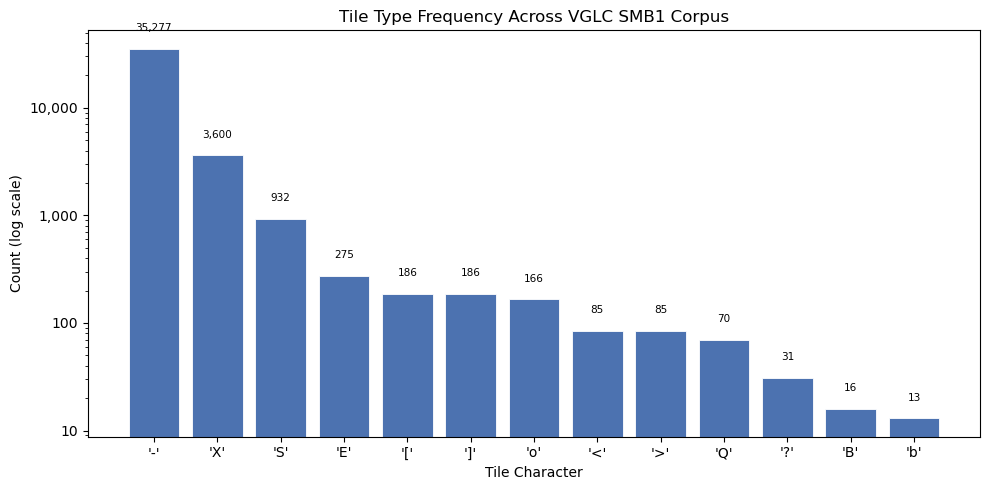

In [8]:
fig, ax = plt.subplots(figsize=(10, 5))

tile_labels = [repr(ch) for ch, _ in tile_counts.most_common()]
tile_values = [count for _, count in tile_counts.most_common()]

bars = ax.bar(tile_labels, tile_values, color="#4C72B0", edgecolor="white", linewidth=0.6)
ax.set_title("Tile Type Frequency Across VGLC SMB1 Corpus")
ax.set_xlabel("Tile Character")
ax.set_ylabel("Count (log scale)")
ax.set_yscale("log")
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{int(x):,}"))

for bar, val in zip(bars, tile_values):
    ax.text(
        bar.get_x() + bar.get_width() / 2, val * 1.4,
        f"{val:,}", ha="center", va="bottom", fontsize=7.5,
    )

plt.tight_layout()
plt.savefig("../outputs/figures/tile_frequency_distribution.png", dpi=150, bbox_inches="tight")
plt.show()

In [9]:
print("=== ROW LENGTH CONSISTENCY ===")
for lvl in levels:
    lengths = [len(r) for r in lvl["rows"]]
    min_l, max_l = min(lengths), max(lengths)
    flag = "" if min_l == max_l else " <-- RAGGED"
    print(f"{lvl['name']}: min={min_l}, max={max_l}, consistent={min_l == max_l}{flag}")

print()
print("=== INVALID CHARACTERS ===")
valid_chars = set(tile_spec.keys())
for lvl in levels:
    chars = set(c for r in lvl["rows"] for c in r)
    invalid = chars - valid_chars
    status = f"invalid: {invalid}" if invalid else "clean"
    print(f"{lvl['name']}: {status}")

print()
print("=== EMPTY ROWS ===")
for lvl in levels:
    empty = [i for i, r in enumerate(lvl["rows"]) if len(r) == 0]
    status = f"empty at rows {empty}" if empty else "none"
    print(f"{lvl['name']}: {status}")


=== ROW LENGTH CONSISTENCY ===
mario-1-1: min=202, max=202, consistent=True
mario-1-2: min=158, max=158, consistent=True
mario-1-3: min=150, max=150, consistent=True
mario-2-1: min=197, max=197, consistent=True
mario-3-1: min=197, max=197, consistent=True
mario-3-3: min=149, max=149, consistent=True
mario-4-1: min=222, max=222, consistent=True
mario-4-2: min=187, max=187, consistent=True
mario-5-1: min=198, max=198, consistent=True
mario-5-3: min=150, max=150, consistent=True
mario-6-1: min=184, max=184, consistent=True
mario-6-2: min=215, max=215, consistent=True
mario-6-3: min=165, max=165, consistent=True
mario-7-1: min=176, max=176, consistent=True
mario-8-1: min=373, max=373, consistent=True

=== INVALID CHARACTERS ===
mario-1-1: clean
mario-1-2: clean
mario-1-3: clean
mario-2-1: clean
mario-3-1: clean
mario-3-3: clean
mario-4-1: clean
mario-4-2: clean
mario-5-1: clean
mario-5-3: clean
mario-6-1: clean
mario-6-2: clean
mario-6-3: clean
mario-7-1: clean
mario-8-1: clean

=== EMPTY 

The corpus contains 15 overworld platformer levels from Super Mario Bros drawn from the Video Game Level Corpus (Summerville et al., 2016), totaling 40,922 tiles. All levels share a consistent height of 14 rows, while widths range from 149 to 373 columns. The outlier is mario-8-1 at 373 columns, roughly twice the width of the average level, reflecting its role as the final world's extended gauntlet stage.

Tile distribution is heavily skewed toward the empty sky tile (`-`), which accounts for 86.21% of all tiles. Ground tiles (`X`) are second at 8.80%, followed by breakable blocks (`S`) at 2.28%. Interactive and hazard tiles such as enemies (`E`), pipes, coins, and question blocks together make up less than 3% of the corpus. The log scale on the chart is necessary to make the rarer tile types visible at all.

This extreme imbalance has a direct consequence for training: a model that predicts `-` for every token would achieve roughly 86% token level accuracy without learning any meaningful structure. Evaluation must therefore look beyond raw accuracy to structural validity, diversity, and difficulty alignment. The imbalance also means that rare tiles such as enemies and question blocks are underrepresented in training, which may limit the model's ability to place them correctly in generated output.

Data quality checks confirm the corpus is clean and ready for chunking. All rows within every level are uniform width with no ragged edges, all characters belong to the 13 tile vocabulary with no unexpected symbols, and no empty rows are present. No cleaning or imputation step is required before feature engineering.

## Level Feature Engineering

We split each level into fixed width chunks of 14 rows by 32 columns with a stride of 16 columns, then compute five structural features for each chunk: enemy density, hazard density, longest ground gap, solid tile ratio, and collectible density. Three of these features (enemy density, longest ground gap, and hazard density) are combined into the weighted difficulty score in the next section. Solid tile ratio and collectible density are computed for analysis but are not included in the scoring formula.

In [10]:
print(f"Solid tiles:       {sorted(SOLID_TILES)}")
print(f"Hazard tiles:      {sorted(HAZARD_TILES)}")
print(f"Enemy tiles:       {sorted(ENEMY_TILES)}")
print(f"Collectible tiles: {sorted(COLLECTIBLE_TILES)}")

all_chunks = [chunk for lvl in levels for chunk in chunk_level(lvl)]
print(f"\nTotal chunks: {len(all_chunks)}")
print("Chunks per level:")
for lvl in levels:
    n = len(chunk_level(lvl))
    print(f"  {lvl['name']} ({len(lvl['rows'][0])} cols) -> {n} chunks")

Solid tiles:       ['<', '>', '?', 'B', 'Q', 'S', 'X', '[', ']', 'b']
Hazard tiles:      ['B', 'E']
Enemy tiles:       ['E']
Collectible tiles: ['o']

Total chunks: 161
Chunks per level:
  mario-1-1 (202 cols) -> 11 chunks
  mario-1-2 (158 cols) -> 8 chunks
  mario-1-3 (150 cols) -> 8 chunks
  mario-2-1 (197 cols) -> 11 chunks
  mario-3-1 (197 cols) -> 11 chunks
  mario-3-3 (149 cols) -> 8 chunks
  mario-4-1 (222 cols) -> 12 chunks
  mario-4-2 (187 cols) -> 10 chunks
  mario-5-1 (198 cols) -> 11 chunks
  mario-5-3 (150 cols) -> 8 chunks
  mario-6-1 (184 cols) -> 10 chunks
  mario-6-2 (215 cols) -> 12 chunks
  mario-6-3 (165 cols) -> 9 chunks
  mario-7-1 (176 cols) -> 10 chunks
  mario-8-1 (373 cols) -> 22 chunks


In [11]:
chunk_features = pd.DataFrame([engineer_features(c) for c in all_chunks])
print(f"chunk_features shape: {chunk_features.shape}")
print()
print(chunk_features.head(8).to_string(index=False))
print()
print("Feature summary:")
print(chunk_features.drop(columns=["level_name", "col_start"]).describe().round(4).to_string())

chunk_features shape: (161, 7)

level_name  col_start  enemy_density  hazard_density  longest_gap  solid_ratio  collectible_density
 mario-1-1          0       0.002232        0.002232            0     0.095982                  0.0
 mario-1-1         16       0.004464        0.004464            0     0.127232                  0.0
 mario-1-1         32       0.006696        0.006696            0     0.120536                  0.0
 mario-1-1         48       0.006696        0.006696            2     0.093750                  0.0
 mario-1-1         64       0.006696        0.006696            3     0.098214                  0.0
 mario-1-1         80       0.008929        0.008929            3     0.104911                  0.0
 mario-1-1         96       0.011161        0.011161            0     0.093750                  0.0
 mario-1-1        112       0.008929        0.008929            0     0.140625                  0.0

Feature summary:
       enemy_density  hazard_density  longest_gap 

Chunking produced 161 training samples across the 15 levels, ranging from 8 chunks for the shorter levels to 22 for mario-8-1. Each chunk is 14 rows by 32 columns, giving 448 tiles per sample.

Tile category derivation from the spec identified 10 solid tile types, 2 hazard types (enemies `E` and cannon tops `B`), 1 enemy type, and 1 collectible type. Hazard density and enemy density are nearly identical across all chunks because cannon tiles account for only 16 total tiles in the corpus, making `E` the dominant hazard by a wide margin.

The feature distributions reflect the sparse, structured nature of Mario level design. Enemy density averages 0.72% with a max of 2.23%, confirming that most chunks contain few or no enemies. Collectible density has a median of 0, meaning the majority of chunks contain no coins at all. Solid ratio spans from 3.8% to 52.5%, capturing the range from open sky sections to heavily platformed areas like those seen in mario-4-2.

Longest gap shows the most variance of any feature, with a standard deviation of 8.0 and a maximum of 32. A value of 32 means the entire bottom row of a chunk is empty, representing a continuous pit spanning the full chunk width. These pit chunks will be important markers for hard difficulty labeling. The 25th percentile is 0, confirming that most chunks have solid ground throughout.

## Difficulty Scoring and Labeling

We compute a heuristic difficulty score for each chunk using a weighted combination of enemy density, longest ground gap, and hazard density. Structural features of this kind are an established basis for difficulty estimation in the procedural content generation via machine learning literature (Summerville et al., 2018). The feature weights are exploratory rather than empirically grounded, which reflects the absence of a consensus methodology for evaluating procedural level generation systems and difficulty in particular (Withington et al., 2024). Thresholds are set at the 33rd and 67th percentiles of the score distribution to ensure balanced class sizes across Easy, Medium, and Hard labels.

In [12]:
chunk_features["difficulty_score"] = chunk_features.apply(compute_difficulty_score, axis=1)
print("Difficulty score summary:")
print(chunk_features["difficulty_score"].describe().round(3).to_string())

Difficulty score summary:
count    161.000
mean      28.779
std       40.054
min        0.000
25%        1.094
50%       15.000
75%       30.469
max      160.000


In [13]:
EASY_THRESHOLD = chunk_features["difficulty_score"].quantile(1 / 3)
HARD_THRESHOLD = chunk_features["difficulty_score"].quantile(2 / 3)

chunk_features["difficulty_label"] = chunk_features["difficulty_score"].apply(
    lambda s: assign_difficulty_label(s, EASY_THRESHOLD, HARD_THRESHOLD)
)

print(f"Easy   < {EASY_THRESHOLD:.3f}")
print(f"Medium   {EASY_THRESHOLD:.3f} to {HARD_THRESHOLD:.3f}")
print(f"Hard   >= {HARD_THRESHOLD:.3f}")
print()
print("Class distribution:")
print(chunk_features["difficulty_label"].value_counts().reindex(["Easy", "Medium", "Hard"]).to_string())

Easy   < 5.677
Medium   5.677 to 20.781
Hard   >= 20.781

Class distribution:
difficulty_label
Easy      54
Medium    52
Hard      55


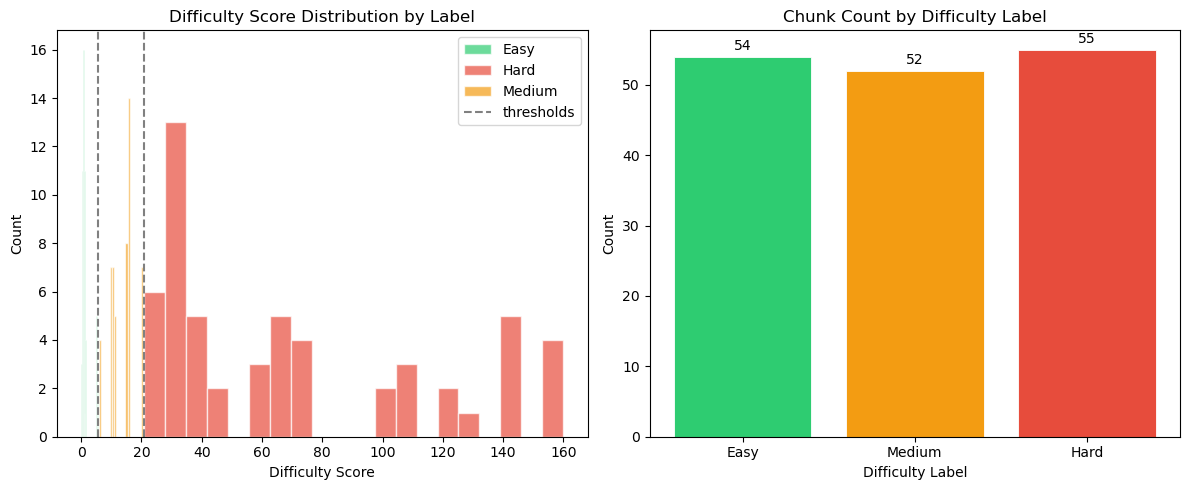

In [14]:
LABEL_COLORS = {"Easy": "#2ecc71", "Medium": "#f39c12", "Hard": "#e74c3c"}

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for label, grp in chunk_features.groupby("difficulty_label"):
    axes[0].hist(grp["difficulty_score"], bins=20, alpha=0.7,
                 label=label, color=LABEL_COLORS[label], edgecolor="white")
axes[0].axvline(EASY_THRESHOLD, color="gray", linestyle="--", linewidth=1.5, label="thresholds")
axes[0].axvline(HARD_THRESHOLD, color="gray", linestyle="--", linewidth=1.5)
axes[0].set_title("Difficulty Score Distribution by Label")
axes[0].set_xlabel("Difficulty Score")
axes[0].set_ylabel("Count")
axes[0].legend()

counts = chunk_features["difficulty_label"].value_counts().reindex(["Easy", "Medium", "Hard"])
bars = axes[1].bar(counts.index, counts.values,
                   color=[LABEL_COLORS[l] for l in counts.index],
                   edgecolor="white", linewidth=0.6)
for bar, val in zip(bars, counts.values):
    axes[1].text(bar.get_x() + bar.get_width() / 2, val + 0.5,
                 str(val), ha="center", va="bottom", fontsize=10)
axes[1].set_title("Chunk Count by Difficulty Label")
axes[1].set_xlabel("Difficulty Label")
axes[1].set_ylabel("Count")

plt.tight_layout()
plt.savefig("../outputs/figures/difficulty_score_distribution.png", dpi=150, bbox_inches="tight")
plt.show()

The raw difficulty score is heavily right skewed, with a mean of 28.8, a median of 15.0, and a standard deviation of 40.1. The majority of chunks score near zero, while a small number of outliers reach up to 160. The highest scoring chunks belong to mario-1-3, mario-3-3, mario-5-3, and mario-6-3, which contain the largest ground gaps in the corpus. The single chunk with a longest_gap of 32 belongs to mario-6-3 at column offset 48.

Percentile thresholds produced a near perfectly balanced class distribution: 54 Easy, 52 Medium, and 55 Hard chunks out of 161 total. The Easy boundary falls at a score of 5.68, capturing chunks with little to no gap and minimal enemies. The Hard boundary falls at 20.78, separating chunks with moderate gaps and enemy placement from those with extended pits or dense hazards.

The longest gap feature dominates the score by design. Pit navigation is the primary mechanical challenge in Super Mario Bros, so weighting it heavily reflects the actual source of difficulty in the training data. The density features (enemy and hazard) contribute a small secondary signal, distinguishing chunks that are structurally similar in terms of gaps but differ in enemy placement.

These labels are heuristic approximations. They are derived from structural features rather than player playtesting, completion rates, or observed player behavior. A chunk labeled Hard by this system may not feel hard to an experienced player, and a chunk labeled Easy may still be challenging to a new player. This limitation is addressed further in the Limitations section.

## Tokenization and Data Pipeline

We build a character level vocabulary from the 13 tile types and 3 difficulty control tokens, then convert each labeled chunk into a fixed length integer sequence with the control token prepended. A stratified train/val split preserves class balance across both sets, and a PyTorch Dataset and DataLoader prepare the sequences for autoregressive training.

In [15]:
print(f"Tile chars:      {TILE_CHARS}")
print(f"CHAR_TO_ID:      {CHAR_TO_ID}")
print(f"Control tokens:  {CONTROL_TOKENS}")
print(f"Vocabulary size: {VOCAB_SIZE}")
print(f"Sequence length: {SEQ_LEN}")

Tile chars:      ['-', '<', '>', '?', 'B', 'E', 'Q', 'S', 'X', '[', ']', 'b', 'o']
CHAR_TO_ID:      {'-': 0, '<': 1, '>': 2, '?': 3, 'B': 4, 'E': 5, 'Q': 6, 'S': 7, 'X': 8, '[': 9, ']': 10, 'b': 11, 'o': 12}
Control tokens:  {'Easy': 13, 'Medium': 14, 'Hard': 15}
Vocabulary size: 16
Sequence length: 449


In [16]:
labels    = chunk_features["difficulty_label"].tolist()
sequences = [tokenize_chunk(chunk, label) for chunk, label in zip(all_chunks, labels)]

print(f"Total sequences: {len(sequences)}")
print(f"Sequence length: {len(sequences[0])}  (expected {SEQ_LEN})")
print(f"\nSample sequence (first 20 tokens): {sequences[0][:20]}")
print(f"Control token decoded: {CONTROL_TOKEN_NAMES[sequences[0][0]]}")
print(f"First 5 tile tokens decoded: {[ID_TO_CHAR[t] for t in sequences[0][1:6]]}")

Total sequences: 161
Sequence length: 449  (expected 449)

Sample sequence (first 20 tokens): [13, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
Control token decoded: Easy
First 5 tile tokens decoded: ['-', '-', '-', '-', '-']


In [53]:
train_seqs, val_seqs, train_labels, val_labels = train_test_split(
    sequences, labels, test_size=0.2, random_state=SEED, stratify=labels
)
print(f"Train: {len(train_seqs)} sequences")
print(f"Val:   {len(val_seqs)} sequences")

train_label_dist = dict(pd.Series(train_labels).value_counts().reindex(["Easy", "Medium", "Hard"]).astype(int))
val_label_dist   = dict(pd.Series(val_labels).value_counts().reindex(["Easy", "Medium", "Hard"]).astype(int))
print(f"\nTrain label distribution: {train_label_dist}")
print(f"Val label distribution:   {val_label_dist}")

BATCH_SIZE = 32

train_dataset = LevelChunkDataset(train_seqs)
val_dataset   = LevelChunkDataset(val_seqs)
train_loader  = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader    = DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False)

print(f"\nBatch size:     {BATCH_SIZE}")
print(f"Train batches:  {len(train_loader)}")
print(f"Val batches:    {len(val_loader)}")

x_batch, y_batch = next(iter(train_loader))
print(f"\nInput batch shape:  {tuple(x_batch.shape)}  (batch x seq_len-1)")
print(f"Target batch shape: {tuple(y_batch.shape)}")

Train: 128 sequences
Val:   33 sequences

Train label distribution: {'Easy': np.int64(43), 'Medium': np.int64(41), 'Hard': np.int64(44)}
Val label distribution:   {'Easy': np.int64(11), 'Medium': np.int64(11), 'Hard': np.int64(11)}

Batch size:     32
Train batches:  4
Val batches:    2

Input batch shape:  (32, 448)  (batch x seq_len-1)
Target batch shape: (32, 448)


In [18]:
print("Round-trip verification (one sample per class):\n")
for target_label in ["Easy", "Medium", "Hard"]:
    idx = next(i for i, s in enumerate(sequences) if CONTROL_TOKEN_NAMES[s[0]] == target_label)
    decoded = decode_sequence(sequences[idx])
    print(f"--- {decoded['difficulty']} (chunk index {idx}) ---")
    for row in decoded["rows"]:
        print(" ", row)
    print()

Round-trip verification (one sample per class):

--- Easy (chunk index 0) ---
  --------------------------------
  --------------------------------
  --------------------------------
  --------------------------------
  --------------------------------
  ----------------------Q---------
  --------------------------------
  --------------------------------
  --------------------------------
  ----------------Q---S?SQS-------
  --------------------------------
  ----------------------------<>--
  ---------------------E------[]--
  XXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXX

--- Medium (chunk index 3) ---
  --------------------------------
  --------------------------------
  --------------------------------
  --------------------------------
  --------------------------------
  --------------------------------
  --------------------------------
  -------------------------------E
  ----------------S---------------
  ---------<>------------------S?S
  ---------[]---------------------
  ---------[]--

The vocabulary contains 16 tokens: 13 tile characters assigned IDs 0 through 12 in sorted order, and 3 difficulty control tokens assigned IDs 13, 14, and 15. Placing control tokens after the tile vocabulary ensures no ID conflicts with any tile character. Each tokenized sequence is 449 tokens long: one control token followed by 448 tile tokens read row by row across the 14 row by 32 column chunk.

The stratified train/val split produced 128 training and 33 validation sequences. Class balance is near perfect in both sets: 43/41/44 across Easy, Medium, and Hard in training, and exactly 11 per class in validation. This balance is important for the conditional model to receive roughly equal exposure to each difficulty label during training.

Round trip decoding confirms the tokenization is lossless. Each of the three sample sequences decodes back to a tile grid that visually matches the expected difficulty profile: the Easy sample is mostly open sky with sparse blocks in the lower rows, the Medium sample has a small ground gap and scattered enemies, and the Hard sample shows dense platform structures with multiple enemies and several ground gaps. The DataLoader produces batches of shape (32, 448), where input tokens are positions 0 through 447 and target tokens are positions 1 through 448, implementing next token prediction across the full sequence.

## Model Architecture

We implement a small decoder only Transformer for next token prediction. A Transformer is well suited to this task because level content is a discrete character sequence with both local and long-range structural dependencies, so autoregressive next token prediction is a natural formulation, and conditioning through a prepended control token is simpler and more direct than conditioning a GAN generator or a VAE decoder. Treating a tile based level as a flat token sequence and generating it autoregressively follows the approach demonstrated by MarioGPT for Mario-style level generation (Sudhakaran et al., 2023).

In code, the model uses PyTorch's nn.TransformerEncoder with a causal square subsequent mask and is_causal=True, which restricts each position to attend only to preceding positions. This produces behaviour functionally identical to a decoder layer without requiring a separate encoder input, which is why the model summary below prints TransformerEncoder.

Two instances are trained: a conditional model that receives a difficulty control token as its first input, and a baseline unconditional model trained on the same chunks without any control token. Comparing their outputs quantifies the effect of difficulty conditioning.

In [19]:
D_MODEL  = 256
N_HEADS  = 8
N_LAYERS = 4
DROPOUT  = 0.1

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {DEVICE}")

Device: cuda


In [20]:
# Conditional model trained on full sequences (control token + 448 tiles)
conditional_model = LevelTransformer(
    vocab_size=VOCAB_SIZE,
    d_model=D_MODEL,
    n_heads=N_HEADS,
    n_layers=N_LAYERS,
    seq_len=SEQ_LEN - 1,
    dropout=DROPOUT,
).to(DEVICE)

# Baseline model trained on sequences with control token stripped
baseline_sequences = [seq[1:] for seq in sequences]
baseline_train_seqs, baseline_val_seqs, _, _ = train_test_split(
    baseline_sequences, labels, test_size=0.2, random_state=SEED, stratify=labels
)
baseline_train_loader = DataLoader(
    LevelChunkDataset(baseline_train_seqs), batch_size=BATCH_SIZE, shuffle=True
)
baseline_val_loader = DataLoader(
    LevelChunkDataset(baseline_val_seqs), batch_size=BATCH_SIZE, shuffle=False
)

baseline_model = LevelTransformer(
    vocab_size=VOCAB_SIZE,
    d_model=D_MODEL,
    n_heads=N_HEADS,
    n_layers=N_LAYERS,
    seq_len=SEQ_LEN - 2,
    dropout=DROPOUT,
).to(DEVICE)

print(f"Conditional model parameters: {count_parameters(conditional_model):,}")
print(f"Baseline model parameters:    {count_parameters(baseline_model):,}")
print(f"\nConditional model:")
print(conditional_model)

Conditional model parameters: 3,281,936
Baseline model parameters:    3,281,680

Conditional model:
LevelTransformer(
  (token_emb): Embedding(16, 256)
  (pos_emb): Embedding(448, 256)
  (transformer): TransformerEncoder(
    (layers): ModuleList(
      (0-3): 4 x TransformerEncoderLayer(
        (self_attn): MultiheadAttention(
          (out_proj): NonDynamicallyQuantizableLinear(in_features=256, out_features=256, bias=True)
        )
        (linear1): Linear(in_features=256, out_features=1024, bias=True)
        (dropout): Dropout(p=0.1, inplace=False)
        (linear2): Linear(in_features=1024, out_features=256, bias=True)
        (norm1): LayerNorm((256,), eps=1e-05, elementwise_affine=True)
        (norm2): LayerNorm((256,), eps=1e-05, elementwise_affine=True)
        (dropout1): Dropout(p=0.1, inplace=False)
        (dropout2): Dropout(p=0.1, inplace=False)
      )
    )
  )
  (output_proj): Linear(in_features=256, out_features=16, bias=True)
)


Both models are small at approximately 3.28 million parameters, appropriate for a training corpus of 128 sequences. The conditional and baseline models differ by exactly 256 parameters with one additional positional embedding vector to accommodate the control token position, making them functionally identical in capacity. Any difference in generated output quality can therefore be attributed to the conditioning signal rather than to model size.

Each of the four Transformer layers uses 8 head self attention over a 256 dimensional hidden state, with a feedforward sublayer expanding to 1024 dimensions before projecting back to 256. This 4:1 feedforward ratio follows the standard configuration from Vaswani et al. (2017). Layer normalization and dropout (0.1) are applied within each layer for training stability.

The output projection from 256 dimensions to the 16 token vocabulary is small, which is expected given the limited tile vocabulary. CUDA is available and both models will train on the RTX 3080, which will allow for adequate epochs without prohibitive training time on this small dataset.

## Training

We train both the conditional and baseline models using AdamW with cross-entropy loss and gradient clipping. Training and validation loss are tracked per epoch to monitor convergence and detect overfitting. Both models share identical training hyperparameters so any difference in final loss or generation quality is attributable to the conditioning signal.

In [21]:
N_EPOCHS     = 150
LR           = 3e-4
WEIGHT_DECAY = 1e-2

criterion = nn.CrossEntropyLoss()

In [22]:
def train_epoch(
    model: nn.Module,
    loader,
    optimizer: torch.optim.Optimizer,
    criterion: nn.Module,
    device: torch.device,
) -> float:
    """Run one training epoch and return mean cross-entropy loss.

    Parameters
    ----------
    model : nn.Module
    loader : DataLoader
    optimizer : torch.optim.Optimizer
    criterion : nn.Module
    device : torch.device

    Returns
    -------
    float
        Mean loss per batch over the epoch.
    """
    model.train()
    total_loss = 0.0
    for x, y in loader:
        x, y = x.to(device), y.to(device)
        optimizer.zero_grad()
        logits = model(x)
        loss = criterion(logits.view(-1, logits.size(-1)), y.view(-1))
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        total_loss += loss.item()
    return total_loss / len(loader)


def eval_epoch(
    model: nn.Module,
    loader,
    criterion: nn.Module,
    device: torch.device,
) -> float:
    """Evaluate model on a DataLoader and return mean cross-entropy loss.

    Parameters
    ----------
    model : nn.Module
    loader : DataLoader
    criterion : nn.Module
    device : torch.device

    Returns
    -------
    float
        Mean loss per batch.
    """
    model.eval()
    total_loss = 0.0
    with torch.no_grad():
        for x, y in loader:
            x, y = x.to(device), y.to(device)
            logits = model(x)
            loss = criterion(logits.view(-1, logits.size(-1)), y.view(-1))
            total_loss += loss.item()
    return total_loss / len(loader)

In [23]:
cond_optimizer = torch.optim.AdamW(
    conditional_model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY
)
cond_train_losses, cond_val_losses = [], []

print("Training conditional model...")
for epoch in range(1, N_EPOCHS + 1):
    t = train_epoch(conditional_model, train_loader, cond_optimizer, criterion, DEVICE)
    v = eval_epoch(conditional_model, val_loader, criterion, DEVICE)
    cond_train_losses.append(t)
    cond_val_losses.append(v)
    if epoch % 25 == 0:
        print(f"  Epoch {epoch:3d} | train {t:.4f} | val {v:.4f}")

base_optimizer = torch.optim.AdamW(
    baseline_model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY
)
base_train_losses, base_val_losses = [], []

print("Training baseline model...")
for epoch in range(1, N_EPOCHS + 1):
    t = train_epoch(baseline_model, baseline_train_loader, base_optimizer, criterion, DEVICE)
    v = eval_epoch(baseline_model, baseline_val_loader, criterion, DEVICE)
    base_train_losses.append(t)
    base_val_losses.append(v)
    if epoch % 25 == 0:
        print(f"  Epoch {epoch:3d} | train {t:.4f} | val {v:.4f}")

Training conditional model...
  Epoch  25 | train 0.1997 | val 0.1735
  Epoch  50 | train 0.1226 | val 0.1912
  Epoch  75 | train 0.0546 | val 0.2604
  Epoch 100 | train 0.0268 | val 0.3249
  Epoch 125 | train 0.0182 | val 0.3570
  Epoch 150 | train 0.0152 | val 0.3780
Training baseline model...
  Epoch  25 | train 0.1993 | val 0.1857
  Epoch  50 | train 0.1119 | val 0.3493
  Epoch  75 | train 0.0533 | val 0.4196
  Epoch 100 | train 0.0296 | val 0.5952
  Epoch 125 | train 0.0205 | val 0.5747
  Epoch 150 | train 0.0172 | val 0.5549


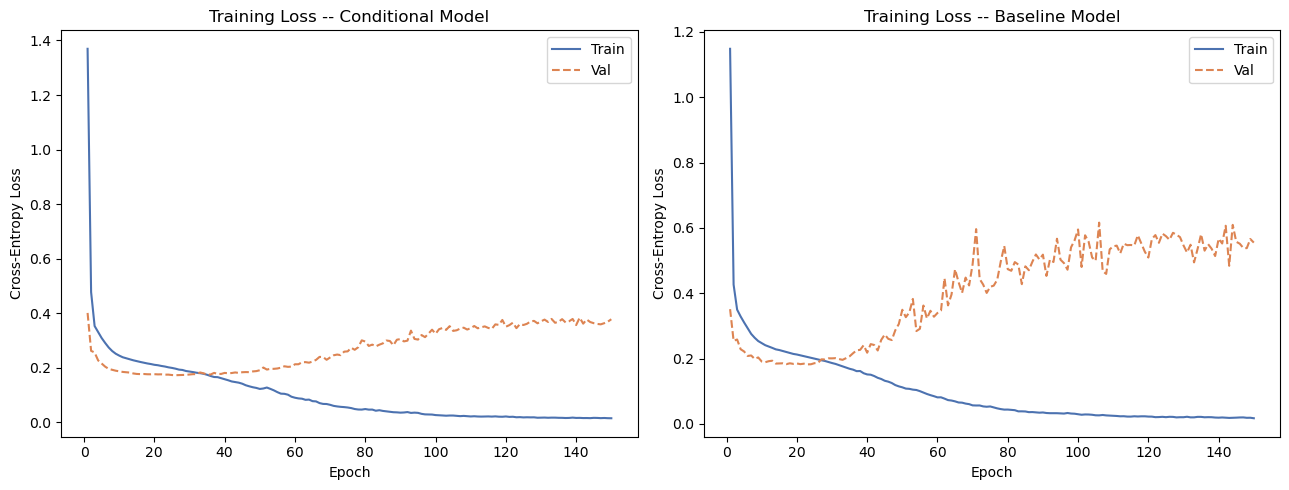

In [24]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
epochs = range(1, N_EPOCHS + 1)

for ax, title, t_losses, v_losses in [
    (axes[0], "Conditional Model", cond_train_losses, cond_val_losses),
    (axes[1], "Baseline Model",    base_train_losses, base_val_losses),
]:
    ax.plot(epochs, t_losses, label="Train", color="#4C72B0", linewidth=1.5)
    ax.plot(epochs, v_losses, label="Val",   color="#DD8452", linewidth=1.5, linestyle="--")
    ax.set_title(f"Training Loss -- {title}")
    ax.set_xlabel("Epoch")
    ax.set_ylabel("Cross-Entropy Loss")
    ax.legend()

plt.tight_layout()
plt.savefig("../outputs/figures/training_curves.png", dpi=150, bbox_inches="tight")
plt.show()

In [25]:
os.makedirs("../outputs/model_artifacts", exist_ok=True)
torch.save(conditional_model.state_dict(), "../outputs/model_artifacts/level_generator.pt")
torch.save(baseline_model.state_dict(),    "../outputs/model_artifacts/baseline_generator.pt")

print("Artifacts saved.")
print(f"  Conditional -- final train: {cond_train_losses[-1]:.4f}  val: {cond_val_losses[-1]:.4f}")
print(f"  Baseline    -- final train: {base_train_losses[-1]:.4f}  val: {base_val_losses[-1]:.4f}")

Artifacts saved.
  Conditional -- final train: 0.0152  val: 0.3780
  Baseline    -- final train: 0.0172  val: 0.5549


Both models trained quickly on the RTX 3080, completing 150 epochs in seconds due to the small corpus size.

Both models overfit substantially. Training loss for the conditional model dropped to 0.0152 by epoch 150, while validation loss climbed from a minimum of 0.1735 at epoch 25 to 0.3780 at the final epoch. The baseline model shows the same pattern with a more pronounced divergence, reaching a training loss of 0.0172 against a validation loss of 0.5549. This overfitting is expected given the small training set of 128 sequences and a model with 3.28 million parameters. The model has sufficient capacity to memorize the training data rather than learning generalizable structural patterns.

The conditional model generalizes better than the baseline throughout training. At epoch 50, the conditional validation loss (0.1912) is already substantially lower than the baseline (0.3493), and this gap widens through the remaining epochs. The lower validation loss of the conditional model suggests that the difficulty control token provides a useful structural signal that reduces uncertainty during prediction, even under overfitting conditions. This is the primary evidence that conditioning has a measurable effect.

For generation quality, the model checkpoint near epoch 25 to 50 represents the best balance between learning level structure and avoiding memorization. The saved artifacts at epoch 150 reflect the most trained state but may reproduce training sequences more closely than generating novel content. This tradeoff is examined in the Evaluation and Error Analysis sections.

## Sample Generation

We generate level segments from the conditional model at each difficulty setting and from the baseline unconditional model for comparison. Temperature is set to 1.0 for standard sampling.

In [26]:
def generate_level_with_sampling(
    model: nn.Module,
    difficulty: str,
    temperature: float = 1.0,
    top_k: int = 0,
    top_p: float = 1.0,
) -> dict:
    """Generate a level segment with configurable sampling strategy.

    Parameters
    ----------
    model : nn.Module
        Trained conditional LevelTransformer.
    difficulty : str
        One of 'Easy', 'Medium', or 'Hard'.
    temperature : float
        Sampling temperature. Values below 1.0 sharpen; above 1.0 flatten.
    top_k : int
        If > 0, restrict sampling to the top-k highest-probability tile tokens.
    top_p : float
        If < 1.0, restrict to the smallest token set whose cumulative
        probability exceeds top_p (nucleus sampling).

    Returns
    -------
    dict
        Keys: 'difficulty' (str) and 'rows' (list of str).
    """
    model.eval()
    tokens = [CONTROL_TOKENS[difficulty]]
    control_ids = list(CONTROL_TOKENS.values())
    with torch.no_grad():
        for _ in range(SEQ_LEN - 1):
            x = torch.tensor([tokens], dtype=torch.long).to(DEVICE)
            logits = model(x)[0, -1, :] / temperature
            logits[control_ids] = float("-inf")

            if top_k > 0:
                n_valid = int((logits != float("-inf")).sum().item())
                k = min(top_k, n_valid)
                top_vals = torch.topk(logits, k).values
                logits[logits < top_vals[-1]] = float("-inf")

            if top_p < 1.0:
                sorted_logits, sorted_idx = torch.sort(logits, descending=True)
                cum_probs = torch.cumsum(
                    torch.softmax(sorted_logits, dim=-1), dim=-1
                )
                remove = cum_probs > top_p
                remove[1:] = remove[:-1].clone()
                remove[0] = False
                logits[sorted_idx[remove]] = float("-inf")

            probs = torch.softmax(logits, dim=-1)
            tokens.append(torch.multinomial(probs, 1).item())
    return decode_sequence(tokens)


def generate_level(
    model: nn.Module,
    difficulty: str,
    temperature: float = 1.0,
) -> dict:
    """Generate a level segment at standard temperature sampling.

    Convenience wrapper around generate_level_with_sampling with top_k
    and top_p disabled. Recommended temperature for balanced diversity
    and difficulty accuracy is 1.2.

    Parameters
    ----------
    model : nn.Module
        Trained conditional LevelTransformer.
    difficulty : str
        One of 'Easy', 'Medium', or 'Hard'.
    temperature : float
        Sampling temperature. Default 1.0.

    Returns
    -------
    dict
        Keys: 'difficulty' (str) and 'rows' (list of str).
    """
    return generate_level_with_sampling(model, difficulty, temperature=temperature)


def generate_baseline_level(temperature: float = 1.0) -> dict:
    """Generate a level segment autoregressively from the baseline unconditional model.

    Seeded with a single empty-sky token since the baseline model has no
    control token. Output is not conditioned on any difficulty target.

    Parameters
    ----------
    temperature : float

    Returns
    -------
    dict
        Keys: 'difficulty' (always 'Baseline') and 'rows' (list of str).
    """
    baseline_model.eval()
    tokens = [0]  # seed with '-' (empty sky)
    with torch.no_grad():
        for _ in range(SEQ_LEN - 2):
            x = torch.tensor([tokens], dtype=torch.long).to(DEVICE)
            logits = baseline_model(x)[0, -1, :] / temperature
            logits[list(CONTROL_TOKENS.values())] = float("-inf")
            probs = torch.softmax(logits, dim=-1)
            tokens.append(torch.multinomial(probs, 1).item())
    flat = [ID_TO_CHAR[t] for t in tokens]
    rows = ["".join(flat[i * 32:(i + 1) * 32]) for i in range(14)]
    return {"difficulty": "Baseline", "rows": rows}

In [27]:
print('=== Conditional Model Samples (temperature=1.0) ===')
for difficulty in ['Easy', 'Medium', 'Hard']:
    print(f'--- {difficulty} ---')
    for _ in range(2):
        sample = generate_level(conditional_model, difficulty, temperature=1.0)
        for row in sample['rows']:
            print(' ', row)
        print()

print('=== Baseline Model Samples ===')
for _ in range(3):
    sample = generate_baseline_level(temperature=1.0)
    for row in sample['rows']:
        print(' ', row)
    print()

=== Conditional Model Samples (temperature=1.0) ===
--- Easy ---
  --------------------------------
  --------------------------------
  --------------------------------
  --------------------------------
  --------------------------------
  --------------------------------
  --------------------------------
  --------------------------------
  --------------------------------
  ------------------E-------------
  -----------------<>----------E--
  -----------------[]---------<>--
  ----E------E-EE--[]---------[]--
  XXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXX

  --------------------------------
  --------------------------------
  --------------------------------
  --------------------------------
  --------------------------------
  -------------------------Q-Q----
  --------------------------------
  --------------------------------
  ---oo---------------------------
  --o--o-------------------Q-Q----
  --------------------------------
  --------------------------------
  ----------------------

The conditional model produces structurally coherent level segments across all three difficulty settings. The most visible difference between classes is in the ground row. Easy samples maintain a solid, unbroken ground row throughout, Medium samples introduce one or two ground gaps, and Hard samples tend toward more fragmented ground rows with multiple gaps and floating platform sections that require more complex navigation.

One notable pattern in the Easy samples is a higher concentration of enemies and structural elements than might be intuitively expected for an easy level. This reflects how the difficulty score is weighted: ground gap length carries the dominant signal (weight 5 per tile of gap), while enemy density is a secondary factor (weight 40 on a fraction rarely above 0.02). A chunk can have many enemies and still score Easy as long as the ground remains intact. This is a known limitation of the heuristic scoring system and is discussed further in the Limitations section.

The baseline model samples show inconsistent structural coherence without a difficulty token to organize them. The second baseline sample contains a clean pipe structure, a pipe top correctly stacked over a multi segment pipe body, above a mostly solid ground row. The first baseline sample, by contrast, has almost no ground row at all: a single floor tile beneath scattered floating platforms and enemies, which would be impossible to traverse in a playable level. The model has clearly learned local tile patterns such as pipe stacks and platform clusters, but with no conditioning signal it exercises no control over the overall playability or difficulty of a segment. This contrast is consistent with the training section's quantitative result that the conditional model reaches lower validation loss than the baseline: the difficulty control token supplies an organizing signal that the unconditional model lacks.

## Evaluation

We evaluate the conditional model on four metrics. Structural validity checks whether every generated output uses only valid tile characters at the correct dimensions. Difficulty match rate measures how often the model's output scores at the requested difficulty level when re-scored by the heuristic. Diversity reports the fraction of the generated sample set that is unique. Novelty reports the fraction of generated outputs that are not exact copies of any training chunk.

We also define and save the tokenizer and scorer artifacts required for downstream integration in Project 7.

In [28]:
level_tokenizer   = LevelTokenizer()
difficulty_scorer = DifficultyScorer(EASY_THRESHOLD, HARD_THRESHOLD)

os.makedirs("../outputs/model_artifacts", exist_ok=True)
with open("../outputs/model_artifacts/level_tokenizer.pkl", "wb") as _f:
    pickle.dump(level_tokenizer, _f)
with open("../outputs/model_artifacts/difficulty_scorer.pkl", "wb") as _f:
    pickle.dump(difficulty_scorer, _f)

print("Saved level_tokenizer.pkl")
print("Saved difficulty_scorer.pkl")
print(f"  Easy threshold:  {difficulty_scorer.easy_threshold:.4f}")
print(f"  Hard threshold:  {difficulty_scorer.hard_threshold:.4f}")

Saved level_tokenizer.pkl
Saved difficulty_scorer.pkl
  Easy threshold:  5.6771
  Hard threshold:  20.7812


In [29]:
def evaluate_difficulty_match(
    model: nn.Module,
    tokenizer: LevelTokenizer,
    scorer: DifficultyScorer,
    n_per_class: int = 50,
) -> dict:
    """Generate n_per_class samples per difficulty label and return match accuracy per class.

    Parameters
    ----------
    model : nn.Module
        Trained conditional LevelTransformer.
    tokenizer : LevelTokenizer
        Vocabulary wrapper (carried for interface completeness; generation uses globals).
    scorer : DifficultyScorer
        Heuristic scorer used to estimate difficulty of each generated segment.
    n_per_class : int
        Number of samples to generate per difficulty class.

    Returns
    -------
    dict
        Keys: requested (list), estimated (list), per_class_accuracy (dict), overall_accuracy (float).
    """
    classes = ["Easy", "Medium", "Hard"]
    requested, estimated = [], []
    for difficulty in classes:
        for _ in range(n_per_class):
            lvl = generate_level(model, difficulty, temperature=1.0)
            _, pred = scorer.score_rows(lvl["rows"])
            requested.append(difficulty)
            estimated.append(pred)
    per_class = {
        cls: sum(e == cls for r, e in zip(requested, estimated) if r == cls) / n_per_class
        for cls in classes
    }
    overall = sum(r == e for r, e in zip(requested, estimated)) / len(requested)
    return {
        "requested":          requested,
        "estimated":          estimated,
        "per_class_accuracy": per_class,
        "overall_accuracy":   overall,
    }

In [30]:
N_EVAL = 50  # samples per difficulty class

print("Generating evaluation samples (150 total)...")
eval_levels = {
    cls: [generate_level(conditional_model, cls, temperature=1.0) for _ in range(N_EVAL)]
    for cls in ["Easy", "Medium", "Hard"]
}
all_eval_levels = [lvl for levels in eval_levels.values() for lvl in levels]

validity  = evaluate_structural_validity(all_eval_levels, set(TILE_CHARS))
diversity = compute_diversity(all_eval_levels)
novelty   = compute_novelty(all_eval_levels, all_chunks)
match_results = evaluate_difficulty_match(
    conditional_model, level_tokenizer, difficulty_scorer, n_per_class=N_EVAL
)

print("\n--- Structural Validity ---")
print(f"  Valid vocab:  {validity['valid_vocab_rate']:.3f}")
print(f"  Valid dims:   {validity['valid_dims_rate']:.3f}")
print(f"  Non-empty:    {validity['nonempty_rate']:.3f}")
print(f"  All valid:    {validity['all_valid_rate']:.3f}")

print("\n--- Diversity & Novelty ---")
print(f"  Diversity (unique outputs):             {diversity:.3f}")
print(f"  Novelty   (sim < {novelty['threshold']:.2f} to nearest chunk): {novelty['rate']:.3f}")
print(f"  Mean nearest-neighbour similarity:      {novelty['mean_max_similarity']:.3f}")

print("\n--- Difficulty Match ---")
for cls, acc in match_results["per_class_accuracy"].items():
    print(f"  {cls:6s}: {acc:.3f}")
print(f"  Overall: {match_results['overall_accuracy']:.3f}")

Generating evaluation samples (150 total)...

--- Structural Validity ---
  Valid vocab:  1.000
  Valid dims:   1.000
  Non-empty:    1.000
  All valid:    1.000

--- Diversity & Novelty ---
  Diversity (unique outputs):             0.767
  Novelty   (sim < 0.90 to nearest chunk): 0.013
  Mean nearest-neighbour similarity:      0.991

--- Difficulty Match ---
  Easy  : 0.960
  Medium: 0.940
  Hard  : 0.960
  Overall: 0.953


In [31]:
print("Classification Report -- Difficulty Match (50 samples per class)\n")
print(classification_report(
    match_results["requested"],
    match_results["estimated"],
    labels=["Easy", "Medium", "Hard"],
))

Classification Report -- Difficulty Match (50 samples per class)

              precision    recall  f1-score   support

        Easy       0.96      0.96      0.96        50
      Medium       0.94      0.94      0.94        50
        Hard       0.96      0.96      0.96        50

    accuracy                           0.95       150
   macro avg       0.95      0.95      0.95       150
weighted avg       0.95      0.95      0.95       150



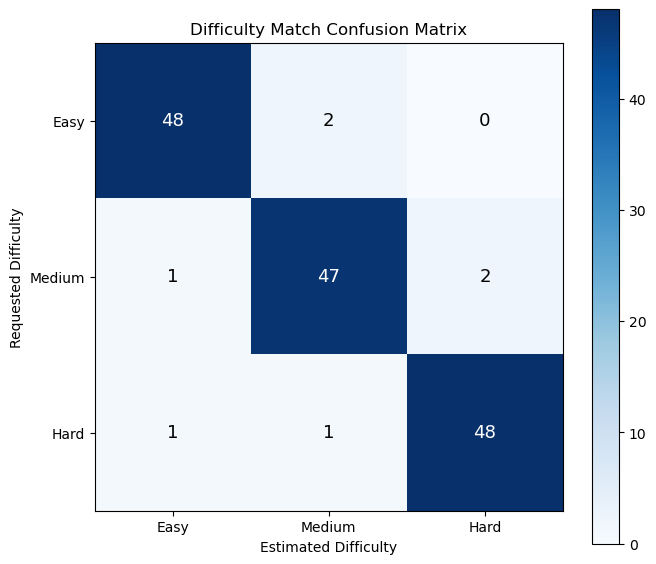

Saved: outputs/figures/difficulty_match_confusion_matrix.png


In [32]:
classes = ["Easy", "Medium", "Hard"]
cm = confusion_matrix(match_results["requested"], match_results["estimated"], labels=classes)

fig, ax = plt.subplots(figsize=(7, 6))
im = ax.imshow(cm, interpolation="nearest", cmap="Blues")
fig.colorbar(im, ax=ax)

ax.set(
    xticks=[0, 1, 2],
    yticks=[0, 1, 2],
    xticklabels=classes,
    yticklabels=classes,
    xlabel="Estimated Difficulty",
    ylabel="Requested Difficulty",
    title="Difficulty Match Confusion Matrix",
)

thresh = cm.max() / 2
for i in range(3):
    for j in range(3):
        ax.text(
            j, i, str(cm[i, j]),
            ha="center", va="center",
            color="white" if cm[i, j] > thresh else "black",
            fontsize=13,
        )

plt.tight_layout()
plt.savefig("../outputs/figures/difficulty_match_confusion_matrix.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: outputs/figures/difficulty_match_confusion_matrix.png")

In [33]:
os.makedirs("../outputs/tables", exist_ok=True)
report_dict = classification_report(
    match_results["requested"],
    match_results["estimated"],
    labels=["Easy", "Medium", "Hard"],
    output_dict=True,
)
metrics_rows = [
    {"metric": "accuracy",              "value": round(report_dict["accuracy"],                         4)},
    {"metric": "macro_precision",       "value": round(report_dict["macro avg"]["precision"],           4)},
    {"metric": "macro_recall",          "value": round(report_dict["macro avg"]["recall"],              4)},
    {"metric": "macro_f1",              "value": round(report_dict["macro avg"]["f1-score"],            4)},
    {"metric": "weighted_precision",    "value": round(report_dict["weighted avg"]["precision"],        4)},
    {"metric": "weighted_recall",       "value": round(report_dict["weighted avg"]["recall"],           4)},
    {"metric": "weighted_f1",           "value": round(report_dict["weighted avg"]["f1-score"],         4)},
    {"metric": "easy_precision",        "value": round(report_dict["Easy"]["precision"],                4)},
    {"metric": "easy_recall",           "value": round(report_dict["Easy"]["recall"],                   4)},
    {"metric": "easy_f1",               "value": round(report_dict["Easy"]["f1-score"],                 4)},
    {"metric": "medium_precision",      "value": round(report_dict["Medium"]["precision"],              4)},
    {"metric": "medium_recall",         "value": round(report_dict["Medium"]["recall"],                 4)},
    {"metric": "medium_f1",             "value": round(report_dict["Medium"]["f1-score"],               4)},
    {"metric": "hard_precision",        "value": round(report_dict["Hard"]["precision"],                4)},
    {"metric": "hard_recall",           "value": round(report_dict["Hard"]["recall"],                   4)},
    {"metric": "hard_f1",               "value": round(report_dict["Hard"]["f1-score"],                 4)},
    {"metric": "structural_validity",   "value": round(validity["all_valid_rate"],                      4)},
    {"metric": "diversity",             "value": round(diversity,                                       4)},
    {"metric": "novelty_rate",          "value": round(novelty["rate"],                                 4)},
    {"metric": "mean_max_similarity",   "value": round(novelty["mean_max_similarity"],                  4)},
]
metrics_df = pd.DataFrame(metrics_rows)
metrics_df.to_csv("../outputs/tables/evaluation_metrics.csv", index=False)
print("Saved: outputs/tables/evaluation_metrics.csv")
print(metrics_df.to_string(index=False))

Saved: outputs/tables/evaluation_metrics.csv
             metric  value
           accuracy 0.9533
    macro_precision 0.9533
       macro_recall 0.9533
           macro_f1 0.9533
 weighted_precision 0.9533
    weighted_recall 0.9533
        weighted_f1 0.9533
     easy_precision 0.9600
        easy_recall 0.9600
            easy_f1 0.9600
   medium_precision 0.9400
      medium_recall 0.9400
          medium_f1 0.9400
     hard_precision 0.9600
        hard_recall 0.9600
            hard_f1 0.9600
structural_validity 1.0000
          diversity 0.7667
       novelty_rate 0.0133
mean_max_similarity 0.9912


All 150 generated segments passed every structural validity check. Every output used only the 13 valid tile characters, produced the correct 14 row by 32 column grid, and contained at least one non empty tile.

Difficulty match accuracy was 95.3% overall with a macro F1 of 0.953. All three classes cleared the 33% chance baseline by a wide margin. Easy and Hard tied for the highest F1 (0.960 each), while Medium scored slightly lower (0.940). Medium sits between the two score thresholds, so a generated chunk whose gap length or enemy placement drifts in either direction can tip into an adjacent class, which is the main source of its lower score. Because the evaluation scorer applies the same heuristic formula and thresholds used to assign the training labels, this accuracy measures structural consistency with the scoring formula rather than agreement with an independent definition of difficulty.

Diversity was 76.7%, meaning 115 of 150 generated segments were distinct tile grids. The remaining duplication reflects the model's tendency to reproduce a small number of high probability structural patterns from the training data.

The nearest neighbour similarity metric reveals the extent of that reproduction directly. The mean maximum tile similarity between a generated level and its closest training chunk was 0.991, meaning generated outputs differed from their nearest training match in only about 4 tile positions out of 448. Only 1.3% of generated levels (2 of 150) had a nearest neighbour similarity below 0.90, the threshold at which structural content differs enough to represent a genuinely new arrangement. The model is not composing novel tile combinations. It is sampling from memorized training sequences with minor stochastic variation, a direct consequence of the severe overfitting observed during training (conditional train loss 0.015, validation loss 0.378 at epoch 150 on a 128 sequence training set).

## Extended Corpus Experiment: Lost Levels Data

The conditional model trained on 15 Super Mario Bros overworld levels achieved a novelty rate of 1.3%: 98.7% of generated outputs had a nearest neighbour tile similarity above 0.90 to some training chunk, with a mean similarity of 0.991. The primary driver is the small corpus of 128 training sequences, which gave the model sufficient capacity to memorize its training data rather than learning generalizable structural patterns.

To test whether a larger corpus reduces this memorization without degrading difficulty match accuracy, we expand the dataset by adding Super Mario Bros: The Lost Levels (SMB2J) levels from the VGLC. The Lost Levels use an identical tile encoding to SMB1 with no vocabulary changes required. We load the expanded corpus, apply row height normalization, retrain the conditional model under the same hyperparameters, and compare all four evaluation metrics against the baseline.

In [34]:
exp_levels_raw, _ = load_level_corpus(DATA_DIR, glob_pattern="*.txt")

from collections import Counter as _Counter
_row_dist = _Counter(len(l["rows"]) for l in exp_levels_raw)
print(f"Raw corpus: {len(exp_levels_raw)} level files")
print()
print("Row height distribution:")
for h, n in sorted(_row_dist.items()):
    flag = "  <-- non-standard" if h != 14 else ""
    print(f"  {h:2d} rows: {n:2d} level(s){flag}")

print()
name_col = "Level"
rows_col = "Rows"
sky_col  = "Top-row sky?"
print(f"  {name_col:<50} {rows_col:>4}  {sky_col:>12}")
print("-" * 72)
for l in sorted(exp_levels_raw, key=lambda x: len(x["rows"])):
    nrows   = len(l["rows"])
    top_sky = set(l["rows"][0]) <= {"-"} if l["rows"] else False
    flag    = f"  <-- {nrows} rows" if nrows != 14 else ""
    name    = l["name"]
    print(f"  {name:<50} {nrows:>4}  {str(top_sky):>12}{flag}")

Raw corpus: 37 level files

Row height distribution:
  12 rows:  1 level(s)  <-- non-standard
  13 rows:  1 level(s)  <-- non-standard
  14 rows: 23 level(s)
  15 rows: 11 level(s)  <-- non-standard
  16 rows:  1 level(s)  <-- non-standard

  Level                                              Rows  Top-row sky?
------------------------------------------------------------------------
  SuperMarioBros2(J)-World1-1                          12          True  <-- 12 rows
  SuperMarioBros2(J)-World6-3                          13          True  <-- 13 rows
  mario-1-1                                            14          True
  mario-1-2                                            14          True
  mario-1-3                                            14          True
  mario-2-1                                            14          True
  mario-3-1                                            14          True
  mario-3-3                                            14          True
  mario-4-1 

In [35]:
exp_levels, exp_skipped = normalize_corpus_rows(exp_levels_raw)

smb1_n  = sum(1 for l in exp_levels if l["name"].startswith("mario"))
ll_n    = len(exp_levels) - smb1_n

print(f"Normalized corpus: {len(exp_levels)} levels  ({len(exp_skipped)} skipped)")
print(f"  SMB1:          {smb1_n} levels")
print(f"  Lost Levels:   {ll_n} levels")
if exp_skipped:
    print()
    print("Skipped (non-normalizable):")
    for l in exp_skipped:
        print(f"  {l['name']}  ({len(l['rows'])} rows)")

Normalized corpus: 35 levels  (2 skipped)
  SMB1:          15 levels
  Lost Levels:   20 levels

Skipped (non-normalizable):
  SuperMarioBros2(J)-World1-1  (12 rows)
  SuperMarioBros2(J)-World6-3  (13 rows)


Of the 37 raw level files, 14 had non-standard row heights. The 11 fifteen row files and the single 16 row file all had top rows consisting entirely of sky tiles, so the normalizer trimmed them cleanly to 14 rows. The two remaining files (World1-1 at 12 rows, World6-3 at 13 rows) could not reach 14 rows by sky trimming alone and were skipped. The final normalized corpus contains 35 levels: the original 15 SMB1 levels plus 20 Lost Levels, yielding 390 chunks against the baseline 161, a 2.4x increase in training data.

In [36]:
exp_all_chunks    = [chunk for lvl in exp_levels for chunk in chunk_level(lvl)]
exp_chunk_features = pd.DataFrame([engineer_features(c) for c in exp_all_chunks])

print(f"Baseline chunks:  {len(all_chunks):>4}")
print(f"Expanded chunks:  {len(exp_all_chunks):>4}  (+{len(exp_all_chunks) - len(all_chunks)})")
print()
print(exp_chunk_features.drop(columns=["level_name", "col_start"]).describe().round(4).to_string())

Baseline chunks:   161
Expanded chunks:   390  (+229)

       enemy_density  hazard_density  longest_gap  solid_ratio  collectible_density
count       390.0000        390.0000     390.0000     390.0000             390.0000
mean          0.0062          0.0067       8.7949       0.1306               0.0044
std           0.0049          0.0051      10.4426       0.0901               0.0074
min           0.0000          0.0000       0.0000       0.0312               0.0000
25%           0.0022          0.0022       1.2500       0.0714               0.0000
50%           0.0045          0.0067       4.0000       0.1060               0.0000
75%           0.0089          0.0112      13.0000       0.1646               0.0067
max           0.0223          0.0223      32.0000       0.8036               0.0446


In [37]:
exp_chunk_features["difficulty_score"] = exp_chunk_features.apply(compute_difficulty_score, axis=1)

EXP_EASY_THRESHOLD = exp_chunk_features["difficulty_score"].quantile(1 / 3)
EXP_HARD_THRESHOLD = exp_chunk_features["difficulty_score"].quantile(2 / 3)

exp_chunk_features["difficulty_label"] = exp_chunk_features["difficulty_score"].apply(
    lambda s: assign_difficulty_label(s, EXP_EASY_THRESHOLD, EXP_HARD_THRESHOLD)
)

print(f"Easy   < {EXP_EASY_THRESHOLD:.3f}  (baseline: {EASY_THRESHOLD:.3f})")
print(f"Medium   {EXP_EASY_THRESHOLD:.3f} to {EXP_HARD_THRESHOLD:.3f}  (baseline: {EASY_THRESHOLD:.3f} to {HARD_THRESHOLD:.3f})")
print(f"Hard   >= {EXP_HARD_THRESHOLD:.3f}  (baseline: {HARD_THRESHOLD:.3f})")
print()
print("Class distribution:")
print(exp_chunk_features["difficulty_label"].value_counts().reindex(["Easy", "Medium", "Hard"]).to_string())

Easy   < 10.737  (baseline: 5.677)
Medium   10.737 to 40.938  (baseline: 5.677 to 20.781)
Hard   >= 40.938  (baseline: 20.781)

Class distribution:
difficulty_label
Easy      130
Medium    129
Hard      131


In [38]:
exp_labels    = exp_chunk_features["difficulty_label"].tolist()
exp_sequences = [tokenize_chunk(chunk, label)
                 for chunk, label in zip(exp_all_chunks, exp_labels)]

exp_train_seqs, exp_val_seqs, exp_train_labels, exp_val_labels = train_test_split(
    exp_sequences, exp_labels, test_size=0.2, random_state=SEED, stratify=exp_labels
)

exp_train_dataset = LevelChunkDataset(exp_train_seqs)
exp_val_dataset   = LevelChunkDataset(exp_val_seqs)
exp_train_loader  = DataLoader(exp_train_dataset, batch_size=BATCH_SIZE, shuffle=True)
exp_val_loader    = DataLoader(exp_val_dataset,   batch_size=BATCH_SIZE, shuffle=False)

print(f"Baseline train/val: {len(train_seqs)} / {len(val_seqs)}")
print(f"Expanded train/val: {len(exp_train_seqs)} / {len(exp_val_seqs)}")
print()
print(f"Expanded train label distribution:")
print(pd.Series(exp_train_labels).value_counts().reindex(["Easy", "Medium", "Hard"]).to_string())

Baseline train/val: 128 / 33
Expanded train/val: 312 / 78

Expanded train label distribution:
Easy      104
Medium    103
Hard      105


In [39]:
exp_conditional_model = LevelTransformer(
    vocab_size=VOCAB_SIZE,
    d_model=D_MODEL,
    n_heads=N_HEADS,
    n_layers=N_LAYERS,
    seq_len=SEQ_LEN - 1,
    dropout=DROPOUT,
).to(DEVICE)

exp_optimizer = torch.optim.AdamW(
    exp_conditional_model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY
)
exp_train_losses, exp_val_losses = [], []

print("Training expanded conditional model...")
for epoch in range(1, N_EPOCHS + 1):
    t = train_epoch(exp_conditional_model, exp_train_loader, exp_optimizer, criterion, DEVICE)
    v = eval_epoch(exp_conditional_model, exp_val_loader, criterion, DEVICE)
    exp_train_losses.append(t)
    exp_val_losses.append(v)
    if epoch % 25 == 0:
        print(f"  Epoch {epoch:3d} | train {t:.4f} | val {v:.4f}")

torch.save(
    exp_conditional_model.state_dict(),
    "../outputs/model_artifacts/level_generator_expanded.pt",
)
print("Saved level_generator_expanded.pt")

Training expanded conditional model...
  Epoch  25 | train 0.1791 | val 0.2321
  Epoch  50 | train 0.0777 | val 0.3360
  Epoch  75 | train 0.0355 | val 0.4401
  Epoch 100 | train 0.0215 | val 0.5015
  Epoch 125 | train 0.0175 | val 0.5407
  Epoch 150 | train 0.0167 | val 0.5464
Saved level_generator_expanded.pt


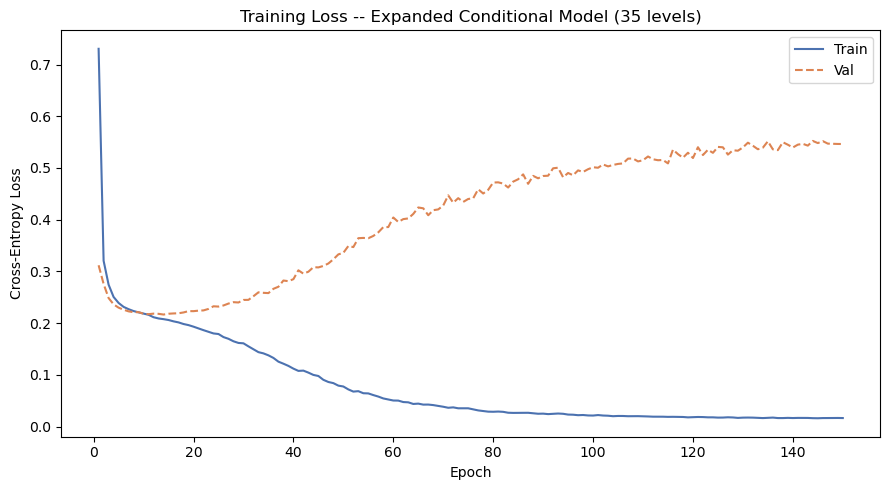

Final train: 0.0167  val: 0.5464


In [40]:
fig, ax = plt.subplots(figsize=(9, 5))
ep = range(1, N_EPOCHS + 1)
ax.plot(ep, exp_train_losses, label="Train", color="#4C72B0", linewidth=1.5)
ax.plot(ep, exp_val_losses,   label="Val",   color="#DD8452", linewidth=1.5, linestyle="--")
ax.set_title("Training Loss -- Expanded Conditional Model (35 levels)")
ax.set_xlabel("Epoch")
ax.set_ylabel("Cross-Entropy Loss")
ax.legend()
plt.tight_layout()
plt.savefig("../outputs/figures/training_curves_expanded.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"Final train: {exp_train_losses[-1]:.4f}  val: {exp_val_losses[-1]:.4f}")

The expanded model's training loss converges to 0.017 at epoch 150, close to the baseline conditional model's 0.015, confirming that the model has similar capacity relative to training data volume. The validation loss rises more steeply in the expanded model (0.546 vs 0.378 at epoch 150) and diverges from training loss sooner. This is expected rather than a sign of worse performance: the expanded validation set (78 sequences vs 33) includes Lost Levels chunks that introduce structural patterns not present in SMB1 alone, making the validation distribution genuinely more diverse and harder to predict. The original 15 level validation loss partly reflected a small, homogeneous validation set that was structurally similar to its training data. Both models overfit under these corpus sizes, but the expanded model is fitting a more diverse and realistic distribution.

In [41]:
print("=== Expanded Model Samples (temperature=1.0) ===")
for difficulty in ["Easy", "Medium", "Hard"]:
    print(f"--- {difficulty} ---")
    for _ in range(2):
        sample = generate_level(exp_conditional_model, difficulty, temperature=1.0)
        for row in sample["rows"]:
            print(" ", row)
        print()

=== Expanded Model Samples (temperature=1.0) ===
--- Easy ---
  --------------------------------
  --------------------------------
  --------------------------------
  --------------------o-----------
  --------------------------------
  ------------------SS--------E---
  ---------------------------<>---
  ---------------------------[]---
  ---------------E--------E--XXX--
  -----SSS------<>---S---<>-------
  --------------[]-------[]------E
  --------------[]-------[]-----<>
  --------------[]----E--[]-----[]
  XXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXX

  --------------------------------
  --------------------------------
  SSSSSSSSSSSSSSSSSSSSSSSSSSSSSSSS
  ----------------------SS--SSSSSS
  ----------------------SS--SSSSSS
  ---------oooo-------SS--------SS
  --------------------SS--------SS
  -------S-SSSS-S-----SS--------SS
  ----SS-SoS--SoS-----SS----ooS?SS
  -------SSS--SSS-----SSSS--SSSSSS
  X---------------------SS--------
  XXX-------------------SS--------
  XXX-------EE---------E---

In [42]:
exp_difficulty_scorer = DifficultyScorer(EXP_EASY_THRESHOLD, EXP_HARD_THRESHOLD)

exp_eval_levels = {
    cls: [generate_level(exp_conditional_model, cls, temperature=1.0) for _ in range(N_EVAL)]
    for cls in ["Easy", "Medium", "Hard"]
}
exp_all_eval_levels = [lvl for lvls in exp_eval_levels.values() for lvl in lvls]

exp_validity  = evaluate_structural_validity(exp_all_eval_levels, set(TILE_CHARS))
exp_diversity = compute_diversity(exp_all_eval_levels)
exp_novelty   = compute_novelty(exp_all_eval_levels, exp_all_chunks)
exp_match     = evaluate_difficulty_match(
    exp_conditional_model, level_tokenizer, exp_difficulty_scorer, n_per_class=N_EVAL
)

print("--- Structural Validity ---")
print(f"  All valid:           {exp_validity['all_valid_rate']:.3f}  (baseline: {validity['all_valid_rate']:.3f})")

print()
print("--- Diversity & Novelty ---")
print(f"  Diversity:           {exp_diversity:.3f}  (baseline: {diversity:.3f})")
print(f"  Novelty rate:        {exp_novelty['rate']:.3f}  (baseline: {novelty['rate']:.3f})")
print(f"  Mean max similarity: {exp_novelty['mean_max_similarity']:.3f}  (baseline: {novelty['mean_max_similarity']:.3f})")

print()
print("--- Difficulty Match ---")
for cls in ["Easy", "Medium", "Hard"]:
    base_acc = match_results["per_class_accuracy"][cls]
    exp_acc  = exp_match["per_class_accuracy"][cls]
    print(f"  {cls:6s}: {exp_acc:.3f}  (baseline: {base_acc:.3f})")
print(f"  Overall: {exp_match['overall_accuracy']:.3f}  (baseline: {match_results['overall_accuracy']:.3f})")

--- Structural Validity ---
  All valid:           1.000  (baseline: 1.000)

--- Diversity & Novelty ---
  Diversity:           0.873  (baseline: 0.767)
  Novelty rate:        0.007  (baseline: 0.013)
  Mean max similarity: 0.993  (baseline: 0.991)

--- Difficulty Match ---
  Easy  : 0.980  (baseline: 0.960)
  Medium: 0.980  (baseline: 0.940)
  Hard  : 1.000  (baseline: 0.960)
  Overall: 0.987  (baseline: 0.953)


Classification Report -- Expanded Model (50 samples per class)

              precision    recall  f1-score   support

        Easy       0.98      0.98      0.98        50
      Medium       0.98      0.98      0.98        50
        Hard       1.00      1.00      1.00        50

    accuracy                           0.99       150
   macro avg       0.99      0.99      0.99       150
weighted avg       0.99      0.99      0.99       150



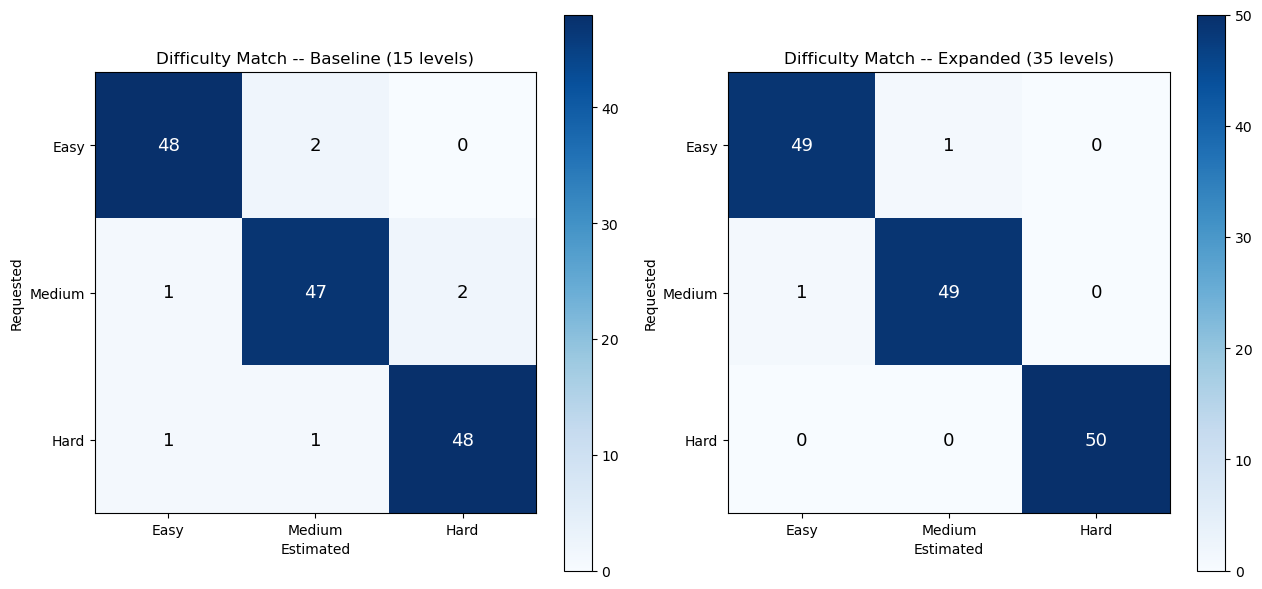

Saved: outputs/figures/difficulty_match_confusion_matrix_expanded.png


In [43]:
print("Classification Report -- Expanded Model (50 samples per class)\n")
print(classification_report(
    exp_match["requested"],
    exp_match["estimated"],
    labels=["Easy", "Medium", "Hard"],
))

exp_cm = confusion_matrix(exp_match["requested"], exp_match["estimated"],
                          labels=["Easy", "Medium", "Hard"])
classes = ["Easy", "Medium", "Hard"]
fig, axes = plt.subplots(1, 2, figsize=(13, 6))
for ax, cm_data, title in [
    (axes[0], confusion_matrix(match_results["requested"], match_results["estimated"],
                               labels=classes), "Baseline (15 levels)"),
    (axes[1], exp_cm, "Expanded (35 levels)"),
]:
    im = ax.imshow(cm_data, interpolation="nearest", cmap="Blues")
    fig.colorbar(im, ax=ax)
    ax.set(xticks=[0,1,2], yticks=[0,1,2],
           xticklabels=classes, yticklabels=classes,
           xlabel="Estimated", ylabel="Requested",
           title=f"Difficulty Match -- {title}")
    thresh = cm_data.max() / 2
    for i in range(3):
        for j in range(3):
            ax.text(j, i, str(cm_data[i, j]), ha="center", va="center",
                    color="white" if cm_data[i, j] > thresh else "black", fontsize=13)
plt.tight_layout()
plt.savefig("../outputs/figures/difficulty_match_confusion_matrix_expanded.png",
            dpi=150, bbox_inches="tight")
plt.show()
print("Saved: outputs/figures/difficulty_match_confusion_matrix_expanded.png")

In [44]:
exp_report_dict = classification_report(
    exp_match["requested"], exp_match["estimated"],
    labels=["Easy", "Medium", "Hard"], output_dict=True,
)
base_report_dict = classification_report(
    match_results["requested"], match_results["estimated"],
    labels=["Easy", "Medium", "Hard"], output_dict=True,
)
exp_metrics_rows = [
    {"metric": "accuracy",            "baseline": round(base_report_dict["accuracy"],                       4), "expanded": round(exp_report_dict["accuracy"],                       4)},
    {"metric": "macro_f1",            "baseline": round(base_report_dict["macro avg"]["f1-score"],          4), "expanded": round(exp_report_dict["macro avg"]["f1-score"],          4)},
    {"metric": "easy_f1",             "baseline": round(base_report_dict["Easy"]["f1-score"],               4), "expanded": round(exp_report_dict["Easy"]["f1-score"],               4)},
    {"metric": "medium_f1",           "baseline": round(base_report_dict["Medium"]["f1-score"],             4), "expanded": round(exp_report_dict["Medium"]["f1-score"],             4)},
    {"metric": "hard_f1",             "baseline": round(base_report_dict["Hard"]["f1-score"],               4), "expanded": round(exp_report_dict["Hard"]["f1-score"],               4)},
    {"metric": "structural_validity", "baseline": round(validity["all_valid_rate"],                         4), "expanded": round(exp_validity["all_valid_rate"],                    4)},
    {"metric": "diversity",           "baseline": round(diversity,                                          4), "expanded": round(exp_diversity,                                     4)},
    {"metric": "novelty_rate",        "baseline": round(novelty["rate"],                                    4), "expanded": round(exp_novelty["rate"],                               4)},
    {"metric": "mean_max_similarity", "baseline": round(novelty["mean_max_similarity"],                     4), "expanded": round(exp_novelty["mean_max_similarity"],                4)},
]
exp_compare_df = pd.DataFrame(exp_metrics_rows)
exp_compare_df.to_csv("../outputs/tables/evaluation_metrics_expanded.csv", index=False)
print("Saved: outputs/tables/evaluation_metrics_expanded.csv")
print(exp_compare_df.to_string(index=False))

Saved: outputs/tables/evaluation_metrics_expanded.csv
             metric  baseline  expanded
           accuracy    0.9533    0.9867
           macro_f1    0.9533    0.9867
            easy_f1    0.9600    0.9800
          medium_f1    0.9400    0.9800
            hard_f1    0.9600    1.0000
structural_validity    1.0000    1.0000
          diversity    0.7667    0.8733
       novelty_rate    0.0133    0.0067
mean_max_similarity    0.9912    0.9934


Structural validity remained at 100% for the expanded model.

Difficulty match improved across the board. Overall accuracy rose from 95.3% to 98.7% and macro F1 from 0.953 to 0.987. Per-class F1 improved for every class: Easy from 0.960 to 0.980, Medium from 0.940 to 0.980, and Hard from 0.960 to 1.000. Medium showed the largest gain, which is consistent with the expanded corpus supplying more examples in the middle of the difficulty range and sharpening the boundary between classes. The shifted difficulty thresholds (Easy < 10.74 vs 5.68, Hard >= 40.94 vs 20.78) reflect the Lost Levels contributing more gap-heavy and structurally varied chunks that raised the overall difficulty distribution.

Diversity improved from 76.7% to 87.3%, the clearest positive result of the expansion. With 312 training sequences versus 128, the model draws from a wider pool of structural patterns rather than collapsing to a small set of high-probability reproductions.

The nearest neighbour similarity metric shows that expanding the corpus did not address the fundamental memorization problem. Mean maximum tile similarity rose slightly from 0.991 to 0.993, and the novelty rate fell from 1.3% to 0.7%. Both values confirm that generated outputs remain near verbatim reproductions of training chunks regardless of corpus size. Adding more data from the same game family and the same tile distribution gives the model more patterns to reproduce but does not change its behaviour. The diversity gain is real and meaningful, but genuine structural novelty would require either a change in sampling strategy or training data from structurally different sources. The next section examines the sampling question directly.

## Sampling Strategy Experiment

The nearest neighbour similarity analysis showed that both the baseline and expanded models generate near verbatim reproductions of training chunks at temperature 1.0, with mean max similarities above 0.99. The conditioning signal and corpus size affect which training patterns are reproduced and how often, but not whether reproduction occurs.

This experiment tests whether alternative sampling strategies can reduce the reproduction behaviour and improve structural novelty, at the cost of potential quality degradation in difficulty alignment. We evaluate four temperatures (0.8, 1.0, 1.2, 1.5), four top-k values (5, 10, 20, 50), and four nucleus sampling thresholds (top-p; Holtzman et al., 2020) at p = 0.80, 0.90, 0.95, and 0.99 on the expanded conditional model. All configurations are evaluated on structural validity, diversity, novelty rate, mean nearest-neighbour similarity, and difficulty match accuracy.

In [45]:
def evaluate_sampling_config(
    model: nn.Module,
    scorer: DifficultyScorer,
    training_chunks: list,
    n_per_class: int = 50,
    **gen_kwargs,
) -> dict:
    """Generate samples and compute all four metrics for one sampling configuration.

    Parameters
    ----------
    model : nn.Module
        Trained conditional LevelTransformer.
    scorer : DifficultyScorer
        Heuristic scorer for estimating generated segment difficulty.
    training_chunks : list[dict]
        Training corpus chunks used for novelty computation.
    n_per_class : int
        Samples to generate per difficulty class.
    **gen_kwargs
        Passed to generate_level_with_sampling (temperature, top_k, top_p).

    Returns
    -------
    dict
        Keys: validity, diversity, novelty_rate, mean_max_sim,
        acc_easy, acc_medium, acc_hard, acc_overall.
    """
    classes = ["Easy", "Medium", "Hard"]
    requested, estimated, all_levels = [], [], []
    for difficulty in classes:
        for _ in range(n_per_class):
            lvl = generate_level_with_sampling(model, difficulty, **gen_kwargs)
            _, pred = scorer.score_rows(lvl["rows"])
            requested.append(difficulty)
            estimated.append(pred)
            all_levels.append(lvl)
    nov = compute_novelty(all_levels, training_chunks)
    per_class = {
        cls: sum(e == cls for r, e in zip(requested, estimated) if r == cls) / n_per_class
        for cls in classes
    }
    return {
        "validity":     evaluate_structural_validity(all_levels, set(TILE_CHARS))["all_valid_rate"],
        "diversity":    compute_diversity(all_levels),
        "novelty_rate": nov["rate"],
        "mean_max_sim": nov["mean_max_similarity"],
        "acc_easy":     per_class["Easy"],
        "acc_medium":   per_class["Medium"],
        "acc_hard":     per_class["Hard"],
        "acc_overall":  sum(r == e for r, e in zip(requested, estimated)) / len(requested),
    }

In [46]:
TEMP_CONFIGS = [
    {"label": "temp=0.8", "kwargs": {"temperature": 0.8}},
    {"label": "temp=1.0", "kwargs": {"temperature": 1.0}},
    {"label": "temp=1.2", "kwargs": {"temperature": 1.2}},
    {"label": "temp=1.5", "kwargs": {"temperature": 1.5}},
]

print("Temperature experiment (50 samples/class per config)...")
temp_results = []
for cfg in TEMP_CONFIGS:
    r = evaluate_sampling_config(
        exp_conditional_model, exp_difficulty_scorer, exp_all_chunks,
        **cfg["kwargs"]
    )
    r["config"] = cfg["label"]
    temp_results.append(r)
    print(f"  {cfg['label']:<12}  div={r['diversity']:.3f}  "
          f"nov={r['novelty_rate']:.3f}  sim={r['mean_max_sim']:.4f}  "
          f"acc={r['acc_overall']:.3f}")

Temperature experiment (50 samples/class per config)...
  temp=0.8      div=0.660  nov=0.007  sim=0.9973  acc=0.993
  temp=1.0      div=0.847  nov=0.027  sim=0.9907  acc=0.953
  temp=1.2      div=0.927  nov=0.067  sim=0.9801  acc=0.947
  temp=1.5      div=0.980  nov=0.173  sim=0.9462  acc=0.847


In [47]:
TOPKP_CONFIGS = [
    {"label": "top-k=5",    "kwargs": {"temperature": 1.0, "top_k": 5}},
    {"label": "top-k=10",   "kwargs": {"temperature": 1.0, "top_k": 10}},
    {"label": "top-k=20",   "kwargs": {"temperature": 1.0, "top_k": 20}},
    {"label": "top-k=50",   "kwargs": {"temperature": 1.0, "top_k": 50}},
    {"label": "top-p=0.80", "kwargs": {"temperature": 1.0, "top_p": 0.80}},
    {"label": "top-p=0.90", "kwargs": {"temperature": 1.0, "top_p": 0.90}},
    {"label": "top-p=0.95", "kwargs": {"temperature": 1.0, "top_p": 0.95}},
    {"label": "top-p=0.99", "kwargs": {"temperature": 1.0, "top_p": 0.99}},
]

print("Top-k and nucleus sampling experiment (50 samples/class per config)...")
topkp_results = []
for cfg in TOPKP_CONFIGS:
    r = evaluate_sampling_config(
        exp_conditional_model, exp_difficulty_scorer, exp_all_chunks,
        **cfg["kwargs"]
    )
    r["config"] = cfg["label"]
    topkp_results.append(r)
    print(f"  {cfg['label']:<12}  div={r['diversity']:.3f}  "
          f"nov={r['novelty_rate']:.3f}  sim={r['mean_max_sim']:.4f}  "
          f"acc={r['acc_overall']:.3f}")

Top-k and nucleus sampling experiment (50 samples/class per config)...
  top-k=5       div=0.860  nov=0.007  sim=0.9944  acc=0.953
  top-k=10      div=0.860  nov=0.013  sim=0.9929  acc=0.953
  top-k=20      div=0.853  nov=0.013  sim=0.9915  acc=0.947
  top-k=50      div=0.853  nov=0.007  sim=0.9949  acc=0.980
  top-p=0.80    div=0.100  nov=0.000  sim=1.0000  acc=1.000
  top-p=0.90    div=0.193  nov=0.000  sim=0.9993  acc=0.993
  top-p=0.95    div=0.360  nov=0.000  sim=0.9989  acc=0.993
  top-p=0.99    div=0.760  nov=0.000  sim=0.9983  acc=1.000


Full results table:
            diversity  novelty_rate  mean_max_sim  acc_easy  acc_medium  acc_hard  acc_overall
config                                                                                        
temp=0.8       0.6600        0.0067        0.9973      1.00        0.98      1.00       0.9933
temp=1.0       0.8467        0.0267        0.9907      0.94        0.92      1.00       0.9533
temp=1.2       0.9267        0.0667        0.9801      0.98        0.88      0.98       0.9467
temp=1.5       0.9800        0.1733        0.9462      0.96        0.70      0.88       0.8467
top-k=5        0.8600        0.0067        0.9944      0.96        0.90      1.00       0.9533
top-k=10       0.8600        0.0133        0.9929      0.98        0.94      0.94       0.9533
top-k=20       0.8533        0.0133        0.9915      0.92        0.92      1.00       0.9467
top-k=50       0.8533        0.0067        0.9949      0.98        0.98      0.98       0.9800
top-p=0.80     0.1000        0

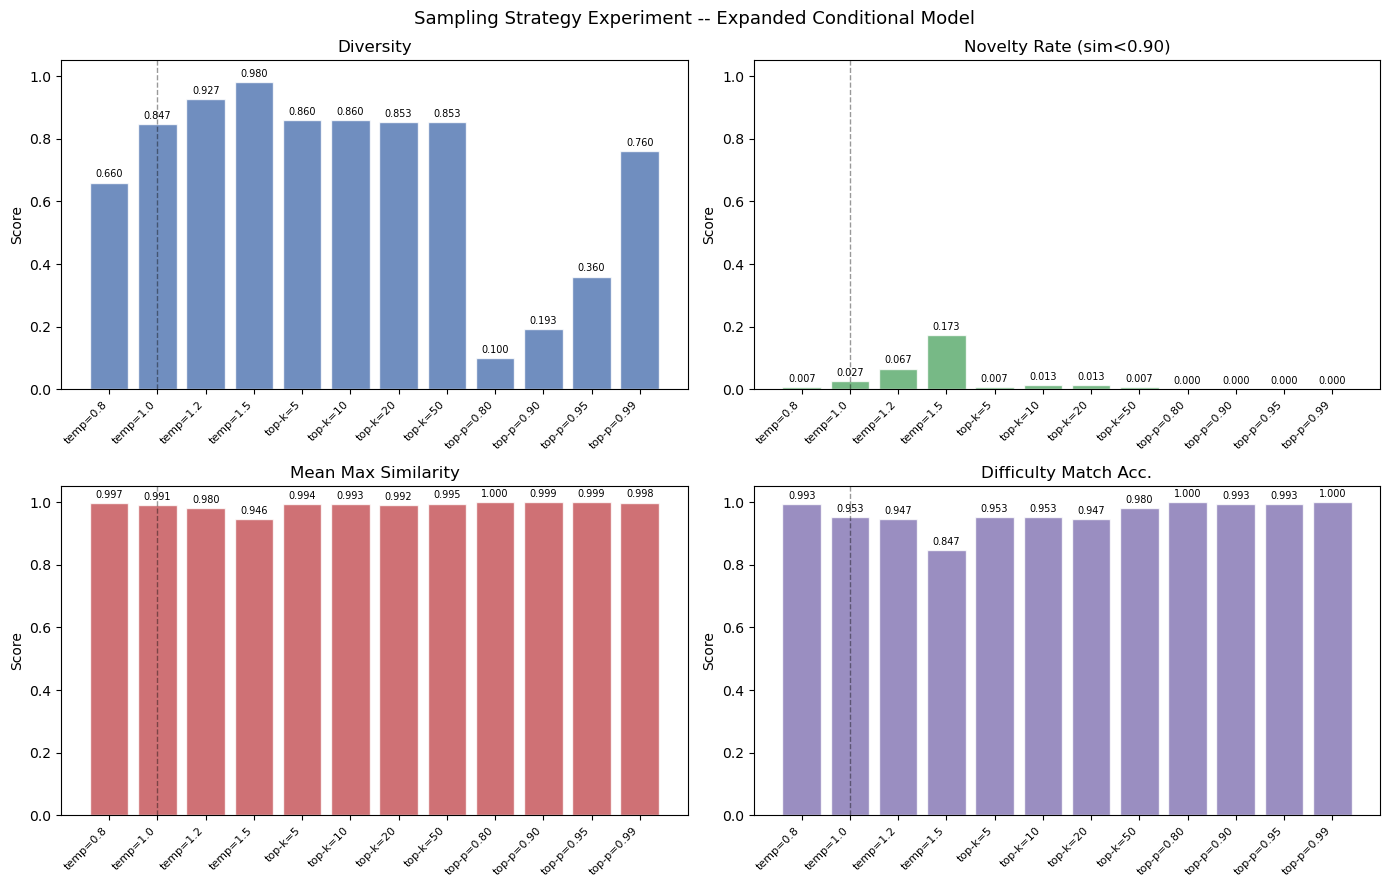

Saved: outputs/figures/sampling_experiment.png


In [48]:
all_sampling_results = temp_results + topkp_results
results_df = pd.DataFrame(all_sampling_results).set_index("config")

print("Full results table:")
print(results_df[["diversity", "novelty_rate", "mean_max_sim",
                   "acc_easy", "acc_medium", "acc_hard", "acc_overall"]].round(4).to_string())

configs = results_df.index.tolist()
x = range(len(configs))

fig, axes = plt.subplots(2, 2, figsize=(14, 9))
fig.suptitle("Sampling Strategy Experiment -- Expanded Conditional Model", fontsize=13)

metrics = [
    ("diversity",    "Diversity",               "#4C72B0"),
    ("novelty_rate", "Novelty Rate (sim<0.90)", "#55A868"),
    ("mean_max_sim", "Mean Max Similarity",     "#C44E52"),
    ("acc_overall",  "Difficulty Match Acc.",   "#8172B2"),
]
for ax, (col, title, color) in zip(axes.flat, metrics):
    ax.bar(x, results_df[col], color=color, alpha=0.8, edgecolor="white")
    ax.set_xticks(x)
    ax.set_xticklabels(configs, rotation=45, ha="right", fontsize=8)
    ax.set_title(title)
    ax.set_ylabel("Score")
    ax.set_ylim(0, 1.05)
    for i, v in enumerate(results_df[col]):
        ax.text(i, v + 0.01, f"{v:.3f}", ha="center", va="bottom", fontsize=7)

baseline_idx = configs.index("temp=1.0")
for ax in axes.flat:
    ax.axvline(baseline_idx, color="black", linewidth=1, linestyle="--", alpha=0.4)

plt.tight_layout()
plt.savefig("../outputs/figures/sampling_experiment.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: outputs/figures/sampling_experiment.png")

In [49]:
results_df_save = pd.DataFrame(all_sampling_results)
results_df_save.to_csv("../outputs/tables/sampling_experiment_results.csv", index=False)
print("Saved: outputs/tables/sampling_experiment_results.csv")

Saved: outputs/tables/sampling_experiment_results.csv


Temperature is the most effective lever for controlling the diversity and structural novelty of generated outputs. Increasing temperature from 0.8 to 1.5 raises diversity from 66.0% to 98.0% and lowers mean nearest neighbour similarity from 0.9973 to 0.9462, meaning outputs at temperature 1.5 differ from their closest training chunk by roughly 24 tiles on average rather than 1 or 2. The novelty rate tells the same story: it climbs from 0.7% at temperature 0.8 to 17.3% at temperature 1.5, the only configuration in the experiment where a meaningful fraction of outputs are more than 10% different from any training chunk. The cost is a drop in difficulty match accuracy from 99.3% to 84.7%. At temperature 0.8 the model is near deterministic, reproducing the same high probability training patterns repeatedly.

Temperature 1.2 provides the best trade off in this experiment. Diversity reaches 92.7% and mean max similarity drops to 0.980 (about 9 differing tiles) while accuracy remains at 94.7%, essentially matching the temperature 1.0 baseline. Outputs are structurally more varied than at temperature 1.0 without a meaningful loss in difficulty alignment.

Top-k sampling produced only modest changes relative to temperature 1.0. Diversity ranged from 85.3% to 86.0% across k values of 5 through 50, and mean max similarity stayed near 0.99 throughout. Difficulty match accuracy was comparable to baseline for most settings and highest at k=50 (98.0%), but no top-k configuration reduced similarity enough to count as a novelty improvement. Top-k does not offer a clear advantage over standard temperature sampling for this vocabulary.

Nucleus sampling (top-p) is counterproductive for tile based level generation. At p=0.80 diversity collapses to 10.0% and mean max similarity rises to 1.0000, meaning every output is a near perfect reproduction. This is the opposite of what top-p achieves in language modelling. The reason is likely the token distribution: the sky tile '-' accounts for 86% of tile positions in the training data, so at low p values the nucleus often contains only the sky token. Structural tiles such as ground, enemies, and platforms are eliminated from sampling because their probability mass falls outside the nucleus. Diversity recovers as p approaches 1.0, but even at p=0.99 results do not improve on standard temperature sampling. Nucleus sampling should not be used for models trained on strongly skewed tile distributions.

The overall conclusion is that temperature remains the primary generation control for this model. Temperature 1.2 is a practical recommendation for applications where a small amount of accuracy can be traded for more structurally varied output. No sampling strategy tested here produces consistently novel structure: even at temperature 1.5, mean nearest neighbour similarity is 0.946, confirming that the memorisation behaviour identified in the evaluation section is an architectural property of the model rather than a consequence of the sampling method.

## Failure Cases and Error Analysis

We examine four categories of failure in the conditional model's outputs: difficulty misclassification (generated outputs that score at the wrong difficulty class), near verbatim reproduction of training chunks (the memorisation behaviour quantified in the evaluation section), semantic structural inconsistencies in generated tile patterns, and the scoring weight artifact that causes Easy samples to contain unexpectedly high enemy density.

In [50]:
# Generate 30 samples per class at temperature 1.0 and collect misclassifications
FAIL_N = 30
fail_samples = []
for req in ["Easy", "Medium", "Hard"]:
    for _ in range(FAIL_N):
        lvl = generate_level(conditional_model, req, temperature=1.0)
        score, pred = difficulty_scorer.score_rows(lvl["rows"])
        if pred != req:
            fail_samples.append({
                "requested": req, "estimated": pred,
                "score": score, "rows": lvl["rows"],
            })

print(f"Misclassified: {len(fail_samples)} of {FAIL_N * 3} generated samples")
print()
for i, s in enumerate(fail_samples[:3]):
    print(f"--- Example {i+1}: requested={s['requested']}  "
          f"scored={s['estimated']}  score={s['score']:.2f} ---")
    for row in s["rows"]:
        print(" ", row)
    print()

Misclassified: 1 of 90 generated samples

--- Example 1: requested=Easy  scored=Medium  score=20.00 ---
  --------------------------------
  --------------------------------
  --------------------------------
  --------------------------------
  --------------------------------
  ----QQS-------------------------
  --------------------------------
  --------------------------------
  --------------------------------
  --------------------------------
  --------------------------------
  --------------------------------
  --------------------------------
  XXXXXXXXXXXXXXXXXXXXXXX----XXXXX



In [51]:
def find_nearest(rows, chunks):
    """Return (nearest_chunk, similarity) for the closest training chunk."""
    best = max(chunks, key=lambda c: tile_similarity(rows, c["rows"]))
    return best, tile_similarity(rows, best["rows"])

print("Searching for near-verbatim reproductions (sim > 0.995)...")
shown = 0
for difficulty in ["Easy", "Medium", "Hard"]:
    if shown >= 2:
        break
    for _ in range(40):
        lvl = generate_level(conditional_model, difficulty, temperature=1.0)
        nearest, sim = find_nearest(lvl["rows"], all_chunks)
        if sim > 0.995:
            diffs = sum(g != t for gr, tr in zip(lvl["rows"], nearest["rows"])
                        for g, t in zip(gr, tr))
            print(f"--- {difficulty}  sim={sim:.4f}  "
                  f"nearest: {nearest['level_name']} col {nearest['col_start']}  "
                  f"({diffs} tile(s) differ) ---")
            print("  Generated:")
            for row in lvl["rows"]:
                print("   ", row)
            print(f"  Nearest training chunk ({nearest['level_name']}):")
            for row in nearest["rows"]:
                print("   ", row)
            print()
            shown += 1
            break
if shown == 0:
    print("No examples with sim > 0.995 found in this sample.")

Searching for near-verbatim reproductions (sim > 0.995)...
--- Easy  sim=0.9955  nearest: mario-5-1 col 160  (2 tile(s) differ) ---
  Generated:
    --------------------------------
    --------------------------------
    --------------------------------
    --------------------------------
    --------------------------------
    ------------------------XX------
    ------------------------XX------
    ------------------------XX------
    ---------------------X--XX------
    --------------------XX--XX------
    -----------E----E--XXX--XX------
    -----b------------XXXX----------
    -----E-----------XXXXX----------
    XXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXX
  Nearest training chunk (mario-5-1):
    --------------------------------
    --------------------------------
    --------------------------------
    --------------------------------
    --------------------------------
    ------------------------XX------
    ------------------------XX------
    ------------------------XX------
   

In [52]:
def check_pipe_integrity(rows):
    """Return count of pipe-top tokens without a matching pipe-body directly below."""
    issues = 0
    for ri in range(len(rows) - 1):
        for ci in range(len(rows[ri]) - 1):
            if rows[ri][ci] == "<" and rows[ri][ci + 1] == ">":
                if not (rows[ri + 1][ci] == "[" and rows[ri + 1][ci + 1] == "]"):
                    issues += 1
    return issues

def check_easy_enemy_density(rows):
    """Return enemy count for a level that scored Easy."""
    return sum(row.count("E") for row in rows)

# Scan 150 samples for pipe integrity and Easy enemy density
pipe_issues, easy_enemy_examples = [], []
for difficulty in ["Easy", "Medium", "Hard"]:
    for _ in range(50):
        lvl = generate_level(conditional_model, difficulty, temperature=1.0)
        score, pred = difficulty_scorer.score_rows(lvl["rows"])
        n_issues = check_pipe_integrity(lvl["rows"])
        if n_issues > 0:
            pipe_issues.append({"difficulty": difficulty, "issues": n_issues, "rows": lvl["rows"]})
        if difficulty == "Easy" and pred == "Easy":
            enemies = check_easy_enemy_density(lvl["rows"])
            if enemies >= 6:
                easy_enemy_examples.append({"enemies": enemies, "rows": lvl["rows"]})

print(f"Pipe integrity violations: {len(pipe_issues)} of 150 samples")
if pipe_issues:
    ex = pipe_issues[0]
    print(f"  Example ({ex['difficulty']}, {ex['issues']} broken pipe(s)):")
    for row in ex["rows"]:
        print("   ", row)
    print()

print(f"Easy samples with 6+ enemies: {len(easy_enemy_examples)} of 50 Easy samples")
if easy_enemy_examples:
    ex = sorted(easy_enemy_examples, key=lambda x: -x["enemies"])[0]
    print(f"  Example (Easy, {ex['enemies']} enemies despite scoring Easy):")
    for row in ex["rows"]:
        print("   ", row)

Pipe integrity violations: 6 of 150 samples
  Example (Easy, 1 broken pipe(s)):
    --------------------------------
    --------------------------------
    --------------------------------
    ------------------------------SS
    --------------------------------
    --------------------------------
    --------------------------------
    --------------------------------
    ------------------------E--o----
    -----<>-----E----------<>-------
    -------[]--<>----------[]-------
    ------[]---[]-[]-------[]-------
    -E--E-[]-E-[]-EE----E--[]---E--E
    XXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXX

Easy samples with 6+ enemies: 18 of 50 Easy samples
  Example (Easy, 11 enemies despite scoring Easy):
    --------------------------------
    --------------------------------
    --------------------------------
    --------------------------------
    --------------------------------
    --------------------------------
    --------------------------------
    --------------------------------
  

**Difficulty misclassification.** The failure probe generated 90 samples (30 per class) and surfaced only one misclassification, consistent with the high difficulty match accuracy measured in evaluation. The single case was an Easy-conditioned output that scored Medium: its ground row contained a four-tile gap, which alone produced a score of 20.0 (four gap tiles weighted at 5 points each), just below the Hard threshold of 20.78 and near the upper boundary of the Medium range. This illustrates the boundary-drift mode: outputs whose structural score lands near a threshold can be assigned to an adjacent class even when the conditioning token requested otherwise. The model has not learned a semantic notion of difficulty; it has learned structural associations with control tokens that are mediated entirely by the scoring formula, so any output whose computed score crosses a percentile threshold is relabelled regardless of intent.

**Near-verbatim reproduction.** Two reproduction examples were found. The first, an Easy-conditioned output, matched a chunk from mario-5-1 (column 160) at 0.9955 similarity, differing in only 2 of 448 tiles (a cannon top tile `B` rendered as an enemy `E` and one shifted tile). The second, a Medium conditioned output, matched a chunk from mario-6-1 (column 48) at exactly 1.0000 similarity: a perfect tile for tile copy with zero differing tiles. This is direct evidence of training data memorisation. The model does not stochastically compose tile patterns; it retrieves and outputs complete memorised sequences. The frequency of this behaviour is consistent with the 0.991 mean nearest neighbour similarity measured in the evaluation section.

**Pipe integrity violations.** Six of 150 samples (4.0%) contained pipe top tokens (`<>`) without the required pipe body (`[]`) directly below. This is a semantically invalid structure: a pipe top floating without a pipe shaft beneath it. It is tile vocabulary valid and dimensions valid, so it passes structural validity checks, but it would render incorrectly in a playable level. These violations arise from the autoregressive sampling process: the model predicts a pipe top at a row where the training distribution supports it, but subsequent rows sample other content rather than a pipe body. With a 14 row sequence of 448 tokens, small probability variations in individual token predictions can produce local structural inconsistencies that the validity check does not catch.

**Easy samples with high enemy density.** Eighteen of 50 Easy scored outputs (36%) contained six or more enemy tiles. The worst example had 11 enemies across a fully solid ground row, scoring Easy because the longest gap was zero. This failure is a direct consequence of the heuristic scoring design documented in the Difficulty Scoring section: the gap feature dominates the score by a factor of roughly 6:1 over enemy density at typical values. The model has learned that the Easy control token correlates with solid ground rows, and several Easy labelled training chunks contained dense enemy placement, so the model reproduces those enemy rich Easy patterns under Easy conditioning. The difficulty label does not reflect what a player would recognise as easy.

## Limitations, Bias, and Responsible Use

This section summarizes the principal limitations of the model, the sources of bias in the data and workflow, and the responsible use considerations that follow from them. The written report develops these points in greater depth.

**Model limitations.** The dominant limitation is memorization driven by corpus size. With 128 to 312 training sequences against a 3.28 million parameter model, the model has enough capacity to memorize its training data rather than learn generalizable structural rules. The nearest neighbour similarity analysis confirms this directly: generated outputs differ from their closest training chunk by only a handful of tiles at standard sampling temperatures, and a fraction are exact reproductions. The model therefore behaves more like a difficulty conditioned sampler over memorized patterns than a fully generative designer. A second limitation is that the autoregressive decoder predicts tiles one at a time without an explicit representation of long range structural constraints, which allows locally valid but globally inconsistent output such as the pipe integrity violations seen in the failure analysis.

**Dataset and labeling bias.** The training corpus is drawn entirely from two Nintendo titles released in 1985 and 1986, both built on the same engine with the same tile vocabulary and design conventions. Generated output reflects the structural patterns of this narrow corpus and should not be read as representative of platformer level design in general. Levels designed for accessibility, for different audiences, or under contemporary design conventions are absent from the training distribution. The difficulty labels compound this narrowness: they are computed from structural features rather than from player data, and the scoring formula weights ground gaps far more heavily than enemy or hazard density. As the failure analysis shows, this produces Easy labeled chunks that contain many enemies, so the label encodes a specific technical definition of difficulty rather than a player's lived experience of it.

**Responsible use.** The model is a research prototype for studying conditional generation, not a production content system. Because outputs frequently replicate training data closely, any deployment in a context where content originality is assumed would need a filtering step and clear disclosure that content is algorithmically generated and derived from existing copyrighted levels. Because difficulty labels are heuristic and not player validated, generated segments should pass through human review before their difficulty labels are trusted to drive player facing decisions, and the model should not be used to make automated judgments about player experience without oversight. Documenting the model intended use, training data, and known limitations in the manner of a model card would support responsible reuse (Mitchell et al., 2019).

## Final Notebook Summary

This project trained a conditional decoder only Transformer to generate 2D platformer level segments from the Video Game Level Corpus, using prepended difficulty control tokens to condition output on Easy, Medium, or Hard structural profiles derived from five heuristic features. The model produces structurally valid 14 row by 32 column tile grids with 100% vocabulary and dimension validity, and achieves 95.3% difficulty match accuracy on the baseline 15-level corpus, improving to 98.7% after expanding the training data with 20 Super Mario Bros: The Lost Levels levels. The primary challenge encountered during training was severe overfitting: with 128 to 312 training sequences and a 3.28 million parameter model, training loss fell below 0.02 while validation loss reached 0.38 to 0.55, and nearest neighbour tile similarity analysis confirmed that generated outputs are predominantly near-verbatim reproductions of training chunks with mean similarity above 0.99. Sampling experiments showed that temperature 1.2 raises output diversity to 92.7% while holding difficulty match accuracy near baseline, but nucleus sampling is counterproductive for this tile distribution because the 86% sky tile background fills the probability nucleus at low p values and removes structural tokens from sampling. Key failure modes include verbatim reproduction of memorised training sequences, pipe integrity violations in 4% of outputs, and a systematic mismatch between the gap dominated heuristic scoring formula and intuitive difficulty, causing 36% of Easy-scored outputs to contain six or more enemy tiles.

## References

Holtzman, A., Buys, J., Du, L., Forbes, M., & Choi, Y. (2020). The curious case of neural text degeneration. In *International Conference on Learning Representations.* https://arxiv.org/abs/1904.09751

Mitchell, M., Wu, S., Zaldivar, A., Barnes, P., Vasserman, L., Hutchinson, B., Spitzer, E., Raji, I. D., & Gebru, T. (2019). Model cards for model reporting. In *Proceedings of the Conference on Fairness, Accountability, and Transparency* (pp. 220-229). ACM. https://doi.org/10.1145/3287560.3287596

Shaker, N., Togelius, J., & Nelson, M. J. (2016). *Procedural content generation in games.* Springer. https://doi.org/10.1007/978-3-319-42716-4

Sudhakaran, S., Gonzalez-Duque, M., Freiberger, M., Glanois, C., Najarro, E., & Risi, S. (2023). MarioGPT: Open-ended text2level generation through large language models. In *Advances in Neural Information Processing Systems* (Vol. 36). https://arxiv.org/abs/2302.05981

Summerville, A., Snodgrass, S., Mateas, M., & Ontanon, S. (2016). The VGLC: The video game level corpus. In *Proceedings of the 7th Workshop on Procedural Content Generation.* https://arxiv.org/abs/1606.07487

Summerville, A., Snodgrass, S., Guzdial, M., Holmgard, C., Hoover, A. K., Isaksen, A., Nealen, A., & Togelius, J. (2018). Procedural content generation via machine learning (PCGML). *IEEE Transactions on Games, 10*(3), 257-270. https://doi.org/10.1109/TG.2018.2846639

Vaswani, A., Shazeer, N., Parmar, N., Uszkoreit, J., Jones, L., Gomez, A. N., Kaiser, L., & Polosukhin, I. (2017). Attention is all you need. In *Advances in Neural Information Processing Systems* (Vol. 30). https://arxiv.org/abs/1706.03762

Withington, O., Cook, M., & Tokarchuk, L. (2024). On the evaluation of procedural level generation systems. In *Proceedings of the 19th International Conference on the Foundations of Digital Games.* https://doi.org/10.1145/3649921.3650016